# Europlátano - Análisis de Producción (TSV)

Este notebook analiza el dataset de producción y genera un informe reproducible con:
- calidad de datos,
- estadística descriptiva,
- relaciones con `Kilos` (target),
- propuesta de variables relevantes para modelado.

**Archivo esperado**: `runtime.test/data/europlatano/produccion.tsv`


## 0) Setup
Imports, configuración y utilidades de visualización.


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception as exc:
    SCIPY_AVAILABLE = False
    stats = None
    print(f"[WARN] scipy no disponible: {exc}")

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from statsmodels.graphics.tsaplots import plot_acf
    from statsmodels.tsa.seasonal import STL
    STATSMODELS_AVAILABLE = True
except Exception as exc:
    STATSMODELS_AVAILABLE = False
    sm = None
    smf = None
    STL = None
    plot_acf = None
    print(f"[WARN] statsmodels no disponible: {exc}")

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)


def display_df(df: pd.DataFrame, title: str = "", n: int = 10):
    if title:
        display(Markdown(f"**{title}**"))
    display(df.head(n))


def top_values_table(df: pd.DataFrame, col: str, n: int = 10) -> pd.DataFrame:
    vc = df[col].fillna("<NA>").astype(str).value_counts(dropna=False).head(n)
    return vc.rename_axis(col).reset_index(name="count")

print(f"Seed fijada en {SEED}")


Seed fijada en 42


## 1) Carga y parsing
- Lectura robusta del TSV.
- Resolución de columnas por alias, conservando nombres originales del archivo.
- Parsing de fecha sobre la columna temporal original.
- Conversión numérica de producción/área/clima en sus columnas originales.
- Conversión de semana a entero (`Semana_num`) si existe o se puede derivar.

In [2]:
DATA_AVAILABLE = False
DATA_PATH = None

# Variables globales de columnas (se resuelven automáticamente con nombres originales del TSV)
COL_DATE = None
COL_TARGET = None
COL_AREA = None
COL_CATEGORY = None
COL_WEEK = None
COL_WEEK_NUM = "Semana_num"
COL_FCA = None
COL_FARM = None
COL_ALTITUDE = None
COL_ISLAND = None
CLIMATE_COLS = []
COLUMN_MAP = {}

candidate_paths = [
    Path("../../data/europlatano/produccion.tsv"),
    Path("../data/europlatano/produccion.tsv"),
    Path("runtime.test/data/europlatano/produccion.tsv"),
    Path("/Users/oroncal/workspace/projects/picota/runtime.test/data/europlatano/produccion.tsv"),
    # Fallback al nombre antiguo
    Path("../../data/europlatano/europlatano.tsv"),
    Path("../data/europlatano/europlatano.tsv"),
    Path("runtime.test/data/europlatano/europlatano.tsv"),
    Path("/Users/oroncal/workspace/projects/picota/runtime.test/data/europlatano/europlatano.tsv"),
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path.resolve()
        break

if DATA_PATH is None:
    print("[INFO] No se encontró el archivo TSV.")
    print("Coloca el dataset en: runtime.test/data/europlatano/produccion.tsv")
    df_raw = pd.DataFrame()
    df = pd.DataFrame()
else:
    print(f"[INFO] Cargando dataset desde: {DATA_PATH}")
    read_error = None
    for enc in ("utf-8", "utf-8-sig", "latin1"):
        try:
            df_raw = pd.read_csv(DATA_PATH, sep="\t", encoding=enc, dtype=str)
            print(f"[INFO] Lectura OK con encoding={enc}")
            break
        except Exception as exc:
            read_error = exc
            df_raw = None
    if df_raw is None:
        raise RuntimeError(f"No se pudo leer el TSV. Último error: {read_error}")

    df = df_raw.copy()
    print(f"[INFO] Columnas originales detectadas ({len(df.columns)}): {list(df.columns)}")

    import re
    import unicodedata

    def normalize_col_name(name: str) -> str:
        txt = unicodedata.normalize("NFKD", str(name))
        txt = "".join(ch for ch in txt if not unicodedata.combining(ch))
        txt = txt.strip().lower()
        txt = re.sub(r"[^a-z0-9]+", "", txt)
        return txt

    def unique_non_null(seq):
        out = []
        seen = set()
        for item in seq:
            if item is None:
                continue
            if item in seen:
                continue
            out.append(item)
            seen.add(item)
        return out

    logical_aliases = {
        "date": ["instant", "fecha", "date", "datetime", "timestamp", "time", "eventtime"],
        "target": ["production", "produccion", "kilos", "kilo", "kg", "kilogramos"],
        "area": ["area", "m2", "superficie", "surface", "aream2", "metros2"],
        "category": ["category", "categoria", "cat", "grade", "tipo"],
        "week": ["semana", "week", "weekiso", "isoweek"],
        "fca": ["fca", "farmcode", "farmid", "codigofca", "codfinca"],
        "farm": ["finca", "farm", "plot", "explotacion"],
        "altitude": ["altitud", "altitude"],
        "island": ["isla", "island"],
        "tmed": ["tmed", "temperaturamedia", "temperatureaverage", "temperaturemean", "territorytemperatureaverage", "tempavg"],
        "tmin": ["tmin", "temperaturaminima", "temperaturemin", "territorytemperaturemin", "tempmin"],
        "tmax": ["tmax", "temperaturamaxima", "temperaturemax", "territorytemperaturemax", "tempmax"],
        "prec": ["prec", "precipitacion", "precipitation", "territoryprecipitation", "rainfall", "rain"],
        "hrMedia": ["hrmedia", "humedad", "humidity", "territoryhumidity", "relativehumidity"],
        "velmedia": ["velmedia", "velocidadviento", "windspeedaverage", "territorywindspeedaverage", "windspeedavg", "windavg"],
        "dir": ["dir", "direccion", "winddirection", "territorywinddirection", "direccionviento"],
        "racha": ["racha", "windspeedmax", "territorywindspeedmax", "windgust", "gust", "maxwindspeed"],
    }

    normalized_to_original = {}
    for col in df.columns:
        normalized_to_original.setdefault(normalize_col_name(col), []).append(col)

    def resolve_original_col(alias_list):
        for alias in alias_list:
            norm_alias = normalize_col_name(alias)
            originals = normalized_to_original.get(norm_alias, [])
            if originals:
                return originals[0]
        return None

    for logical_name, alias_list in logical_aliases.items():
        COLUMN_MAP[logical_name] = resolve_original_col(alias_list)

    COL_DATE = COLUMN_MAP.get("date")
    COL_TARGET = COLUMN_MAP.get("target")
    COL_AREA = COLUMN_MAP.get("area")
    COL_CATEGORY = COLUMN_MAP.get("category")
    COL_WEEK = COLUMN_MAP.get("week")
    COL_FCA = COLUMN_MAP.get("fca")
    COL_FARM = COLUMN_MAP.get("farm")
    COL_ALTITUDE = COLUMN_MAP.get("altitude")
    COL_ISLAND = COLUMN_MAP.get("island")

    if COL_FARM is None and COL_FCA is not None:
        COL_FARM = COL_FCA
    if COL_FCA is None and COL_FARM is not None:
        COL_FCA = COL_FARM

    if COL_CATEGORY is None:
        COL_CATEGORY = "Category"
        df[COL_CATEGORY] = "missing"

    climate_keys = ["tmed", "tmin", "tmax", "prec", "hrMedia", "velmedia", "dir", "racha"]
    CLIMATE_COLS = unique_non_null([COLUMN_MAP.get(k) for k in climate_keys])

    mapping_report = [
        {"campo_logico": "fecha", "columna_tsv": COL_DATE},
        {"campo_logico": "target", "columna_tsv": COL_TARGET},
        {"campo_logico": "area", "columna_tsv": COL_AREA},
        {"campo_logico": "categoria", "columna_tsv": COL_CATEGORY},
        {"campo_logico": "semana", "columna_tsv": COL_WEEK},
        {"campo_logico": "fca", "columna_tsv": COL_FCA},
        {"campo_logico": "finca", "columna_tsv": COL_FARM},
        {"campo_logico": "altitud", "columna_tsv": COL_ALTITUDE},
        {"campo_logico": "isla", "columna_tsv": COL_ISLAND},
    ]
    mapping_report += [{"campo_logico": f"clima_{k}", "columna_tsv": COLUMN_MAP.get(k)} for k in climate_keys]
    mapping_report = pd.DataFrame(mapping_report)
    display_df(mapping_report, "Resolución de columnas (sin renombrar TSV)", len(mapping_report))

    # Parse de fecha sobre columna original
    if COL_DATE is not None and COL_DATE in df.columns:
        fecha_raw = df[COL_DATE].astype("string")
        fecha_parsed = pd.to_datetime(fecha_raw, errors="coerce", utc=True)
        invalid_fecha = fecha_parsed.isna() & fecha_raw.notna() & (fecha_raw.str.strip() != "")
        print(f"Fechas inválidas en {COL_DATE}: {int(invalid_fecha.sum())}")
        if invalid_fecha.sum() > 0:
            display_df(df.loc[invalid_fecha, [COL_DATE]].drop_duplicates().head(10), "Ejemplos de fecha inválida", 10)
        df[COL_DATE] = fecha_parsed
    else:
        print("[WARN] Columna temporal no encontrada.")

    # Si no hay semana en el TSV, se deriva desde la fecha
    if COL_WEEK is None and COL_DATE is not None and COL_DATE in df.columns:
        iso = df[COL_DATE].dt.isocalendar()
        week = iso.week.astype("Int64")
        year = iso.year.astype("Int64")
        week_txt = week.astype(str).str.zfill(2) + "\\" + year.astype(str)
        week_txt = week_txt.where(week.notna() & year.notna(), pd.NA)
        COL_WEEK = "Semana"
        df[COL_WEEK] = week_txt
        print(f"Semana derivada desde {COL_DATE} en {int(df[COL_WEEK].notna().sum())} filas")

    def to_numeric_with_report(series: pd.Series, col_name: str) -> pd.Series:
        raw = series.astype("string").str.strip()
        cleaned = raw.str.replace(",", ".", regex=False)
        numeric = pd.to_numeric(cleaned, errors="coerce")
        bad_mask = numeric.isna() & raw.notna() & (raw != "")
        print(f"{col_name}: no parseables = {int(bad_mask.sum())}")
        if bad_mask.sum() > 0:
            bad_examples = raw[bad_mask].value_counts().head(10).rename_axis("valor").reset_index(name="count")
            display_df(bad_examples, f"Valores no parseables en {col_name}", 10)
        return numeric

    numeric_parse_cols = unique_non_null([COL_TARGET, COL_AREA, "pescaj", COL_ALTITUDE] + CLIMATE_COLS)
    for c in numeric_parse_cols:
        if c in df.columns:
            df[c] = to_numeric_with_report(df[c], c)

    if CLIMATE_COLS:
        print("Columnas climáticas detectadas:", CLIMATE_COLS)

    if COL_WEEK is not None and COL_WEEK in df.columns:
        semana_num = pd.to_numeric(df[COL_WEEK], errors="coerce")
        semana_extraida = pd.to_numeric(df[COL_WEEK].astype(str).str.extract(r"(\d{1,2})")[0], errors="coerce")
        semana_num = semana_num.fillna(semana_extraida)
        df[COL_WEEK_NUM] = semana_num.astype("Int64")
        print(f"{COL_WEEK} convertida a entero ({COL_WEEK_NUM}) en {int(df[COL_WEEK_NUM].notna().sum())} filas")

    # Campos mínimos para el resto del notebook
    required = [COL_DATE, COL_TARGET]
    missing_required = [c for c in required if c is None or c not in df.columns]
    if missing_required:
        print(f"[WARN] Faltan columnas requeridas: {missing_required}")

    DATA_AVAILABLE = True

if DATA_AVAILABLE:
    print(f"Shape: {df.shape}")
    display_df(df, "Head", 5)
    display_df(df.tail(5), "Tail", 5)




[INFO] Cargando dataset desde: /Users/oroncal/workspace/projects/picota/runtime.test/data/europlatano/produccion.tsv
[INFO] Lectura OK con encoding=utf-8
[INFO] Columnas originales detectadas (15): ['instant', 'fca', 'Category', 'Production', 'Area', 'Territory.Temperature:Average', 'Territory.Temperature:Min', 'Territory.Temperature:Max', 'Territory.Precipitation', 'Territory.Humidity', 'Territory.WindSpeed:Average', 'Territory.WindDirection', 'Territory.WindSpeed:Max', 'Altitude', 'Island']


**Mapeo de columnas aplicado**

,origen,destino
0,instant,Fecha
1,Production,Kilos
2,Area,M2
3,Category,categoria
4,Territory.Temperature:Average,tmed
5,Territory.Temperature:Min,tmin
6,Territory.Temperature:Max,tmax
7,Territory.Precipitation,prec
8,Territory.Humidity,hrMedia
9,Territory.WindSpeed:Average,velmedia


Fechas inválidas: 0
Semana derivada desde Fecha en 1503209 filas
Kilos: no parseables = 0
M2: no parseables = 0
altitud: no parseables = 0
tmed: no parseables = 0
tmin: no parseables = 0
tmax: no parseables = 0
prec: no parseables = 0
hrMedia: no parseables = 0
velmedia: no parseables = 0
dir: no parseables = 0
racha: no parseables = 0
Columnas climáticas detectadas: ['tmed', 'tmin', 'tmax', 'prec', 'hrMedia', 'velmedia', 'dir', 'racha']
Semana convertida a entero (Semana_num) en 1503209 filas
Shape: (1503209, 32)


**Head**

,instant,fca,Category,Production,Area,Territory.Temperature:Average,Territory.Temperature:Min,Territory.Temperature:Max,Territory.Precipitation,Territory.Humidity,Territory.WindSpeed:Average,Territory.WindDirection,Territory.WindSpeed:Max,Altitude,Island,Fecha,Kilos,M2,categoria,tmed,tmin,tmax,prec,hrMedia,velmedia,dir,racha,altitud,isla,finca,Semana,Semana_num
0,2014-12-27T00:00:00.000Z,2YX00,P,96.000,48919.0000,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2014-12-27 00:00:00+00:00,96.0,48919.0,P,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2YX00,52\2014,52
1,2014-12-27T00:00:00.000Z,2YX00,S,80.000,48919.0000,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2014-12-27 00:00:00+00:00,80.0,48919.0,S,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2YX00,52\2014,52
2,2014-12-27T00:00:00.000Z,2YX00,G,1251.000,48919.0000,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2014-12-27 00:00:00+00:00,1251.0,48919.0,G,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2YX00,52\2014,52
3,2014-12-27T00:00:00.000Z,2YX00,B,24.000,48919.0000,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2014-12-27 00:00:00+00:00,24.0,48919.0,B,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2YX00,52\2014,52
4,2014-12-27T00:00:00.000Z,2YX00,J,384.000,48919.0000,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2014-12-27 00:00:00+00:00,384.0,48919.0,J,14.8,9.5,20.0,0.0,58.0,1.4,17,4.7,58,TEN,2YX00,52\2014,52


**Tail**

,instant,fca,Category,Production,Area,Territory.Temperature:Average,Territory.Temperature:Min,Territory.Temperature:Max,Territory.Precipitation,Territory.Humidity,Territory.WindSpeed:Average,Territory.WindDirection,Territory.WindSpeed:Max,Altitude,Island,Fecha,Kilos,M2,categoria,tmed,tmin,tmax,prec,hrMedia,velmedia,dir,racha,altitud,isla,finca,Semana,Semana_num
1503204,2026-02-27T00:00:00.000Z,4ET01,C,110.000,6220.0000,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,2026-02-27 00:00:00+00:00,110.0,6220.0,C,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,4ET01,09\2026,9
1503205,2026-02-27T00:00:00.000Z,2AW00,P,10.000,5288.0000,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,197,PAL,2026-02-27 00:00:00+00:00,10.0,5288.0,P,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,197,PAL,2AW00,09\2026,9
1503206,2026-02-27T00:00:00.000Z,4ET01,G,279.000,6220.0000,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,2026-02-27 00:00:00+00:00,279.0,6220.0,G,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,4ET01,09\2026,9
1503207,2026-02-27T00:00:00.000Z,4ET01,P,5.000,6220.0000,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,2026-02-27 00:00:00+00:00,5.0,6220.0,P,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,4ET01,09\2026,9
1503208,2026-02-27T00:00:00.000Z,4ET01,G,3.000,6220.0000,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,2026-02-27 00:00:00+00:00,3.0,6220.0,G,17.0,14.0,20.0,0.2,85.0,3.3,29,12.2,125,PAL,4ET01,09\2026,9


## 2) Perfilado y calidad de datos
- Tipos y completitud.
- Duplicados exactos y por claves candidatas.
- Cardinalidad de categóricas.
- Identificación de columnas tipo ID y casi constantes.


In [3]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    n_rows = len(df)

    type_table = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
        "nulls": df.isna().sum(),
        "null_%": (df.isna().mean() * 100).round(2),
    }).sort_values(["null_%", "n_unique"], ascending=[False, False])

    display_df(type_table, "Tipos y completitud", len(type_table))

    dup_exact = int(df.duplicated().sum())
    print(f"Duplicados exactos de fila: {dup_exact}")

    candidate_keys = [
        [c for c in [COL_DATE, COL_FARM, "patron", "Orden"] if c is not None],
        [c for c in [COL_DATE, COL_FARM, COL_CATEGORY, "Albaran"] if c is not None],
        [c for c in [COL_DATE, COL_FCA, "Orden"] if c is not None],
        ["Albaran", "AlbLin"],
        ["RegLin"],
    ]

    dup_key_rows = []
    for key in candidate_keys:
        if all(k in df.columns for k in key):
            dup_count = int(df.duplicated(subset=key).sum())
            dup_key_rows.append({
                "key": ", ".join(key),
                "duplicates": dup_count,
                "duplicate_%": round(100 * dup_count / max(1, n_rows), 3),
            })

    if dup_key_rows:
        dup_key_table = pd.DataFrame(dup_key_rows).sort_values("duplicates", ascending=False)
        display_df(dup_key_table, "Duplicados por claves candidatas", len(dup_key_table))

    categorical_cols = [c for c in df.columns if df[c].dtype == "object"]
    card_table = pd.DataFrame({
        "columna": categorical_cols,
        "n_unique": [df[c].nunique(dropna=True) for c in categorical_cols],
        "top_freq_%": [float(df[c].value_counts(dropna=False, normalize=True).iloc[0] * 100) if len(df[c]) else np.nan for c in categorical_cols],
    }).sort_values("n_unique", ascending=False)
    display_df(card_table, "Cardinalidad de columnas categóricas", len(card_table))

    top_values_rows = []
    for c in categorical_cols:
        vc = df[c].fillna("<NA>").astype(str).value_counts(dropna=False).head(10)
        compact = " | ".join([f"{idx} ({cnt})" for idx, cnt in vc.items()])
        top_values_rows.append({"columna": c, "top_10": compact})
    top_values_df = pd.DataFrame(top_values_rows)
    display_df(top_values_df, "Top 10 valores por columna categórica", len(top_values_df))

    id_like_cols = [c for c in df.columns if (df[c].nunique(dropna=False) / max(1, n_rows)) >= 0.98]
    almost_constant_cols = [c for c in df.columns if df[c].value_counts(dropna=False, normalize=True).iloc[0] >= 0.98]

    print("Candidatas a ID (cardinalidad ~ n):", id_like_cols)
    print("Casi constantes:", almost_constant_cols)




**Tipos y completitud**

,dtype,n_unique,nulls,null_%
Production,object,4725,0,0.0
Kilos,Float64,4725,0,0.0
instant,object,3327,0,0.0
Fecha,"datetime64[ns, UTC]",3327,0,0.0
Area,object,1257,0,0.0
M2,Float64,1257,0,0.0
fca,object,1139,0,0.0
finca,object,1139,0,0.0
Semana,object,584,0,0.0
Altitude,object,382,0,0.0


Duplicados exactos de fila: 46754


**Cardinalidad de columnas categóricas**

,columna,n_unique,top_freq_%
3,Production,4725,4.932315
0,instant,3327,0.095462
4,Area,1257,1.403730
1,fca,1139,1.410516
17,finca,1139,1.410516
18,Semana,584,0.305613
13,Altitude,382,2.089530
8,Territory.Precipitation,367,84.698601
7,Territory.Temperature:Max,328,1.110957
5,Territory.Temperature:Average,283,1.866474


**Top 10 valores por columna categórica**

,columna,top_10
0,instant,2024-10-21T00:00:00.000Z (1435) | 2024-10-07T00:00:00.000Z (1433) | 2024-10-28T00:00:00.000Z (1369) | 2023-11-06T00:00:00.000Z (1358) | 2021-02-08T00:00:00.000Z (1321) | 2021-02-22T00:00:00.000Z (...
1,fca,2TK00 (21203) | 2RM00 (17441) | 4J501 (16201) | 2ZQ00 (14366) | 3BF01 (12888) | 21K00 (12709) | 21L00 (12341) | 2RL00 (11323) | 4FC01 (11155) | 4IX01 (9781)
2,Category,G (521151) | E (399215) | P (248387) | S (172855) | B (66073) | V (27743) | J (25575) | C (21377) | X (13305) | M (3189)
3,Production,17.000 (74143) | 34.000 (61701) | 51.000 (51342) | 68.000 (43544) | 85.000 (38623) | 102.000 (33222) | 119.000 (28984) | 19.000 (26557) | 153.000 (26230) | 136.000 (25753)
4,Area,128291.0000 (21101) | 127260.0000 (17320) | 143914.0000 (16201) | 75746.0000 (14366) | 213624.0000 (12801) | 92607.0000 (12709) | 93123.0000 (12091) | 87579.0000 (11323) | 84338.0000 (11119) | 900...
5,Territory.Temperature:Average,19.6 (28057) | 19.2 (27957) | 19.0 (26408) | 20.2 (26156) | 19.4 (26132) | 18.8 (23993) | 18.2 (23917) | 19.8 (23744) | 20.4 (23075) | 18.6 (22986)
6,Territory.Temperature:Min,15.7 (20456) | 16.1 (18817) | 15.5 (18168) | 16.3 (18056) | 16.4 (18007) | 15.4 (17493) | 14.9 (17295) | 14.7 (17252) | 15.3 (17234) | 15.2 (17016)
7,Territory.Temperature:Max,22.4 (16700) | 21.9 (16605) | 23.4 (15960) | 22.2 (15903) | 21.4 (15720) | 22.3 (15651) | 21.8 (15535) | 23.2 (15292) | 21.0 (15182) | 23.9 (15173)
8,Territory.Precipitation,0.0 (1273197) | 0.2 (38955) | 0.4 (16331) | 0.1 (15042) | 0.6 (9652) | 0.8 (9199) | 1.0 (7396) | 1.2 (6905) | 1.4 (6045) | 1.8 (4771)
9,Territory.Humidity,73.0 (54678) | 76.0 (53737) | 70.0 (53712) | 75.0 (51603) | 69.0 (51093) | 74.0 (50910) | 68.0 (50814) | 71.0 (50448) | 72.0 (49903) | 67.0 (49312)


Candidatas a ID (cardinalidad ~ n): []
Casi constantes: []


## 3) Estadística descriptiva
- Descriptivos numéricos.
- Distribución y outliers de `Kilos`.
- Evolución temporal y estacionalidad.
- Agregaciones por variables clave.
- Ratios operativos (`Kilos/M2`).


**Descriptivos numéricos**

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Kilos,1503209.0,305.573968,553.825813,0.001,3.0,12.0,48.0,136.0,357.0,1078.0,2520.0,36135.0
M2,1503209.0,26557.184532,36168.95909,20.0,417.0,1277.0,4549.0,12762.0,31310.0,99039.0,148591.0,213624.0
Semana_num,1503209.0,26.53657,15.637866,1.0,1.0,3.0,12.0,27.0,41.0,50.0,52.0,53.0
ratio_kilos_m2,1503209.0,0.03185,0.097805,0.000002,0.000224,0.000733,0.003754,0.010957,0.03029,0.123917,0.312093,26.35
tmed,1503209.0,19.250846,3.913043,5.8,11.2,13.2,16.4,19.2,21.8,25.6,29.0,39.2
tmin,1503209.0,15.657575,3.749451,1.6,7.3,9.7,13.0,15.6,18.2,21.7,24.8,35.5
tmax,1503209.0,22.836606,4.327454,7.6,14.2,16.2,19.8,22.7,25.6,30.1,33.8,44.3
prec,1503209.0,0.685587,3.723355,0.0,0.0,0.0,0.0,0.0,0.0,3.2,16.9,125.8
hrMedia,1503209.0,67.707333,15.35868,2.0,18.0,35.0,62.0,70.0,77.0,88.0,95.0,100.0
velmedia,1503209.0,2.571678,1.761217,0.0,0.6,0.8,1.4,1.9,3.1,6.4,9.4,15.8


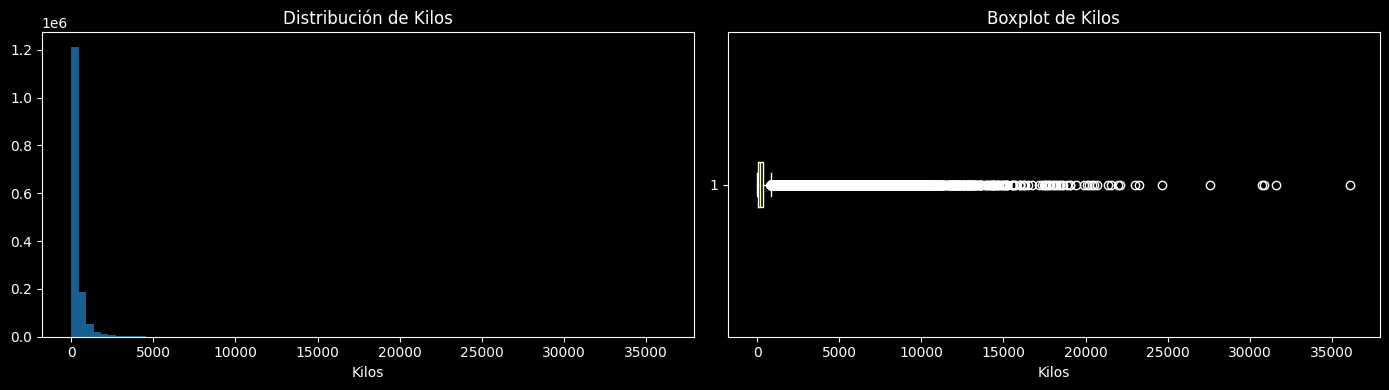

Outliers Kilos por IQR: 120942 filas
Outliers Kilos por z-score > 3: 24829 filas


**Top outliers por IQR (Kilos)**

,Fecha,finca,categoria,Kilos
23248,2015-04-08 00:00:00+00:00,3BF01,G,36135.0
27570,2015-04-24 00:00:00+00:00,3BF01,G,31605.0
366586,2018-09-04 00:00:00+00:00,4HI01,G,30864.0
20116,2015-03-26 00:00:00+00:00,3BF01,G,30735.0
227066,2017-05-14 00:00:00+00:00,20500,G,27585.0
230891,2017-05-28 00:00:00+00:00,20500,G,24660.0
870699,2021-10-25 00:00:00+00:00,2AE00,G,23256.0
106541,2016-03-04 00:00:00+00:00,3BF01,G,23040.0
221362,2017-04-23 00:00:00+00:00,20600,G,22110.0
1097315,2023-08-01 00:00:00+00:00,24B00,G,21964.0


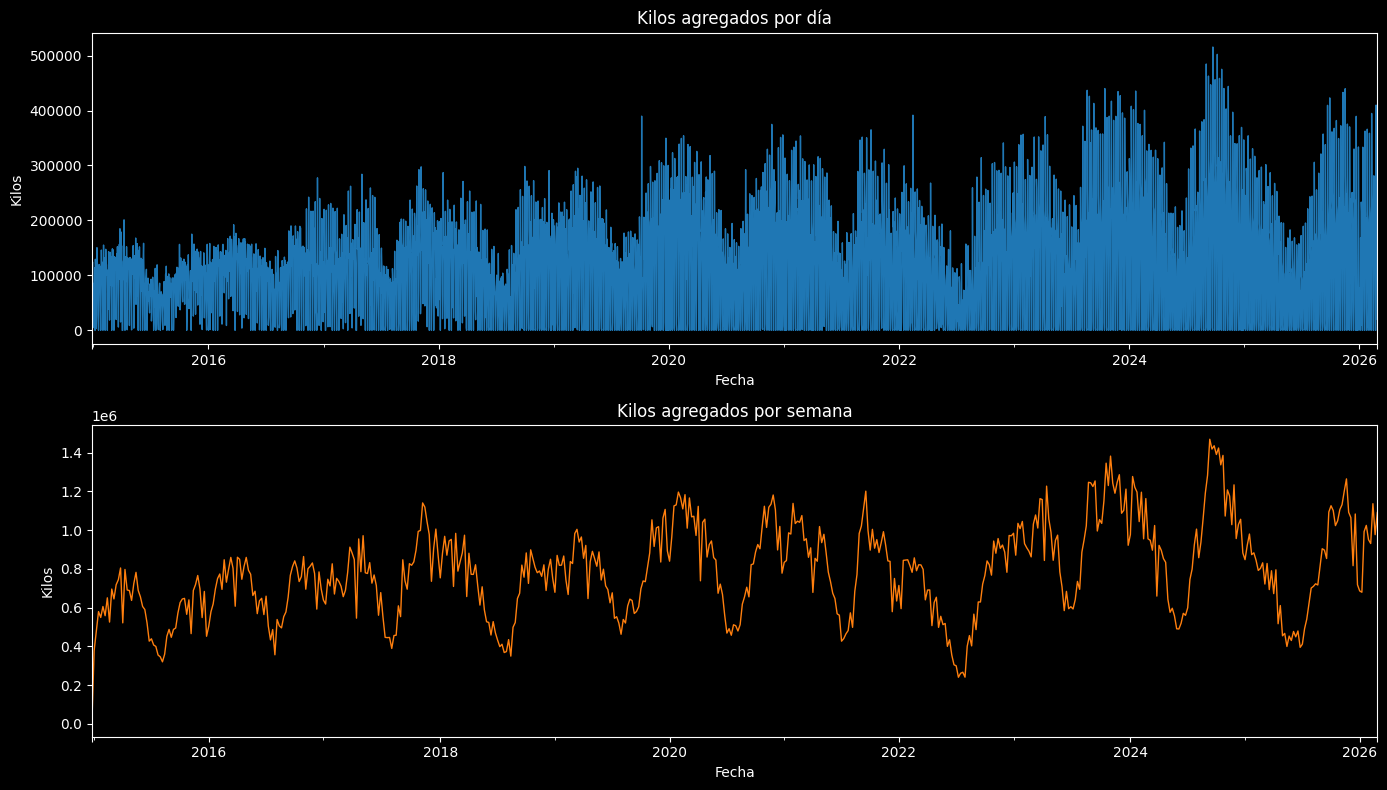

**Estacionalidad por Semana_num**

,mean,median,count
Semana_num,,,
1,328.569188,144.0,26366
2,315.57471,144.0,32633
3,320.721943,144.0,34057
4,328.636555,153.0,33675
5,309.050254,136.0,34664
6,317.601184,153.0,33281
7,325.563199,153.0,31907
8,310.84133,136.0,34222
9,311.287527,136.0,33569


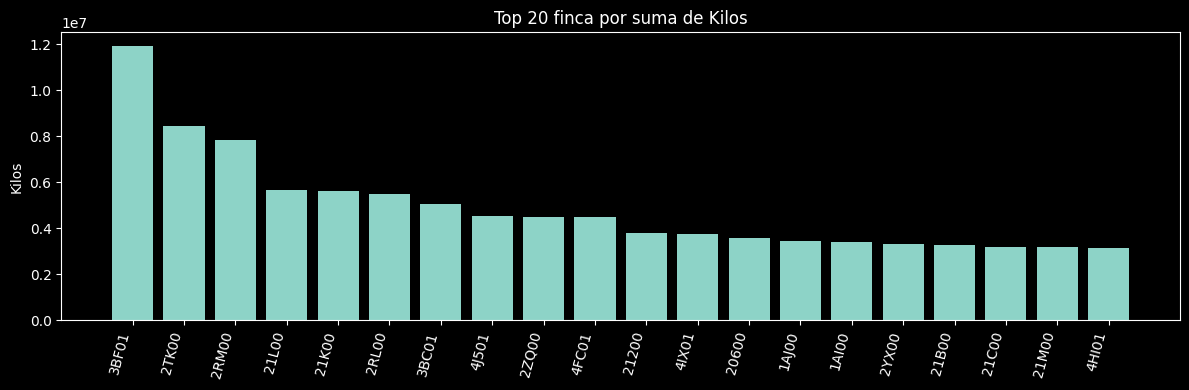

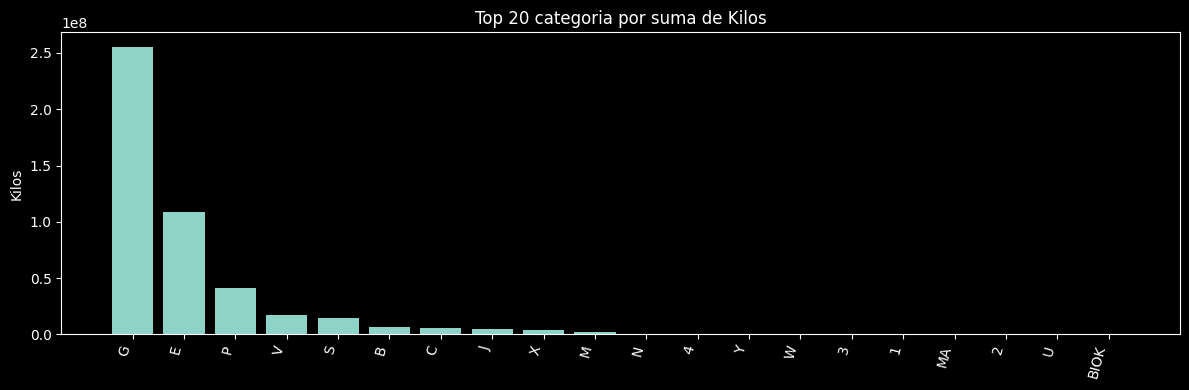

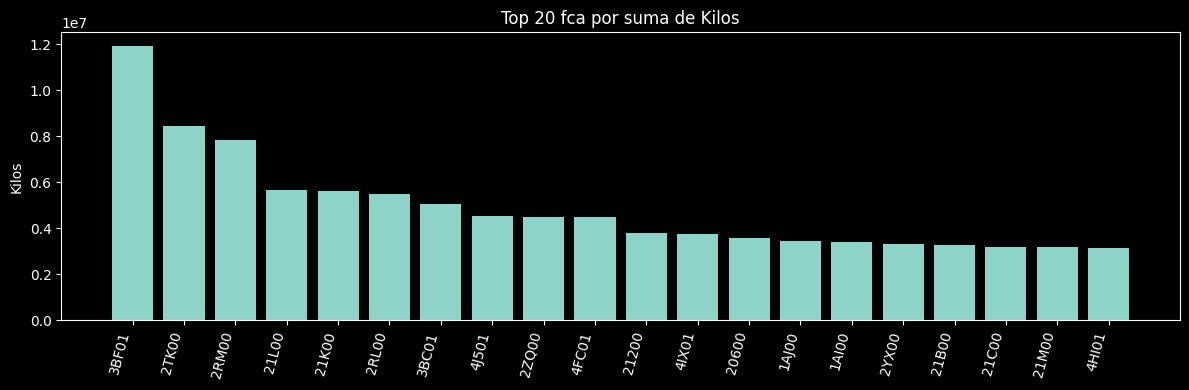

**Resumen de ratios**

,count,mean,std,min,25%,50%,75%,max
ratio_kilos_m2,1503209.0,0.03185,0.097805,0.000002,0.003754,0.010957,0.03029,26.35


In [4]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    for ratio_name, num_col, den_col in [("ratio_kilos_m2", COL_TARGET, COL_AREA)]:
        if num_col in df.columns and den_col in df.columns:
            den = df[den_col].replace(0, np.nan)
            df[ratio_name] = df[num_col] / den

    climate_cols = [c for c in CLIMATE_COLS if c in df.columns]
    numeric_candidates = [c for c in [COL_TARGET, COL_AREA, "pescaj", COL_WEEK_NUM, "ratio_kilos_m2"] if c is not None] + climate_cols
    numeric_cols = [c for c in numeric_candidates if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

    if numeric_cols:
        desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
        display_df(desc, "Descriptivos numéricos", len(desc))

    if COL_TARGET in df.columns:
        kilos = df[COL_TARGET].dropna()
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].hist(kilos, bins=80, color="#1f77b4", alpha=0.8)
        axes[0].set_title("Distribución de Kilos")
        axes[0].set_xlabel(COL_TARGET)

        axes[1].boxplot(kilos, vert=False)
        axes[1].set_title("Boxplot de Kilos")
        axes[1].set_xlabel(COL_TARGET)
        plt.tight_layout()
        plt.show()

        q1, q3 = kilos.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_iqr = (df[COL_TARGET] < lower) | (df[COL_TARGET] > upper)

        print(f"Outliers Kilos por IQR: {int(out_iqr.sum())} filas")

        if SCIPY_AVAILABLE and kilos.shape[0] > 3:
            z_vals = pd.Series(np.nan, index=df.index)
            valid_mask = df[COL_TARGET].notna()
            z_vals.loc[valid_mask] = np.abs(stats.zscore(df.loc[valid_mask, COL_TARGET], nan_policy="omit"))
            out_z = z_vals > 3
            print(f"Outliers Kilos por z-score > 3: {int(out_z.sum())} filas")

        cols_out = [c for c in [COL_DATE, COL_FARM, "patron", COL_CATEGORY, COL_TARGET] if c in df.columns]
        top_out = df.loc[out_iqr, cols_out].sort_values(COL_TARGET, ascending=False).head(20)
        display_df(top_out, "Top outliers por IQR (Kilos)", 20)

    if COL_DATE in df.columns and COL_TARGET in df.columns:
        ts = df.dropna(subset=[COL_DATE, COL_TARGET]).copy()
        if not ts.empty:
            daily = ts.set_index(COL_DATE).resample("D")[COL_TARGET].sum()
            weekly = ts.set_index(COL_DATE).resample("W")[COL_TARGET].sum()

            fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
            daily.plot(ax=axes[0], color="#1f77b4", linewidth=1)
            axes[0].set_title("Kilos agregados por día")
            axes[0].set_ylabel(COL_TARGET)

            weekly.plot(ax=axes[1], color="#ff7f0e", linewidth=1)
            axes[1].set_title("Kilos agregados por semana")
            axes[1].set_ylabel(COL_TARGET)
            plt.tight_layout()
            plt.show()

    if COL_WEEK_NUM in df.columns and COL_TARGET in df.columns:
        season = df.dropna(subset=[COL_WEEK_NUM, COL_TARGET]).groupby(COL_WEEK_NUM)[COL_TARGET].agg(["mean", "median", "count"]).sort_index()
        display_df(season, "Estacionalidad por Semana_num", len(season))

    def plot_top_sum(col: str, top_n: int = 20):
        if col not in df.columns or COL_TARGET not in df.columns:
            return
        agg = (
            df.dropna(subset=[col, COL_TARGET]).groupby(col)[COL_TARGET].sum().sort_values(ascending=False).head(top_n)
        )
        if agg.empty:
            return
        plt.figure(figsize=(12, 4))
        plt.bar(agg.index.astype(str), agg.values)
        plt.title(f"Top {top_n} {col} por suma de Kilos")
        plt.xticks(rotation=75, ha="right")
        plt.ylabel(COL_TARGET)
        plt.tight_layout()
        plt.show()

    for c in [COL_FARM, "patron", COL_CATEGORY, COL_FCA, "Orden", "producto"]:
        plot_top_sum(c, top_n=20)

    ratio_cols = [c for c in ["ratio_kilos_m2"] if c in df.columns]
    if ratio_cols:
        display_df(df[ratio_cols].describe().T, "Resumen de ratios", len(ratio_cols))





## 4) Relaciones entre variables
- Correlación entre numéricas (incluyendo ratios y variables climáticas).
- Categóricas vs `Kilos` (boxplots Top-N).
- Pruebas ANOVA/Kruskal-Wallis y tamaño de efecto.
- Señales temporales con `Kilos`.


**Matriz de correlación (Spearman)**

,Kilos,M2,Semana_num,tmed,tmin,tmax,prec,hrMedia,velmedia,dir,racha,ratio_kilos_m2
Kilos,1.000000,0.385108,0.001072,0.014964,0.013104,0.016011,0.001678,-0.050569,0.098432,-0.022332,0.015011,0.566419
M2,0.385108,1.000000,0.033027,0.087742,0.085418,0.085939,-0.006366,-0.133629,0.267685,-0.050959,0.049630,-0.495605
Semana_num,0.001072,0.033027,1.000000,0.352470,0.388385,0.301161,-0.008128,0.050147,-0.086584,-0.034012,-0.064834,-0.027116
tmed,0.014964,0.087742,0.352470,1.000000,0.960894,0.971798,-0.236523,-0.372659,-0.007362,-0.064370,-0.042503,-0.065689
tmin,0.013104,0.085418,0.388385,0.960894,1.000000,0.872957,-0.165074,-0.286658,-0.008275,-0.065150,-0.056016,-0.064932
tmax,0.016011,0.085939,0.301161,0.971798,0.872957,1.000000,-0.284417,-0.425064,-0.007545,-0.058547,-0.029844,-0.063418
prec,0.001678,-0.006366,-0.008128,-0.236523,-0.165074,-0.284417,1.000000,0.272061,0.101509,-0.008846,0.140713,0.009835
hrMedia,-0.050569,-0.133629,0.050147,-0.372659,-0.286658,-0.425064,0.272061,1.000000,-0.090503,0.063370,-0.055426,0.070267
velmedia,0.098432,0.267685,-0.086584,-0.007362,-0.008275,-0.007545,0.101509,-0.090503,1.000000,-0.089049,0.619315,-0.143452
dir,-0.022332,-0.050959,-0.034012,-0.064370,-0.065150,-0.058547,-0.008846,0.063370,-0.089049,1.000000,-0.123101,0.021863


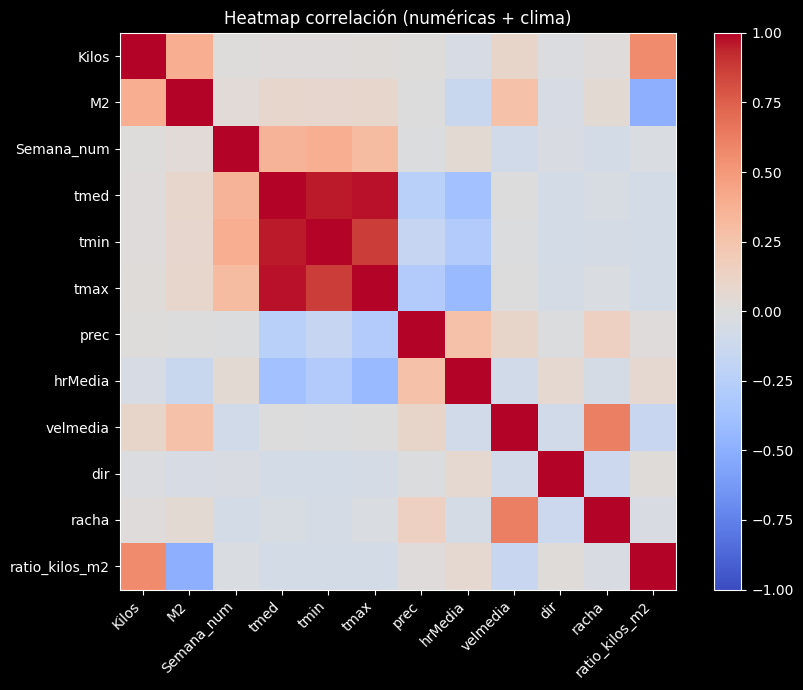

**Correlación clima vs Kilos**

,variable_clima,spearman_rho,n
5,velmedia,0.098432,1503209
4,hrMedia,-0.050569,1503209
6,dir,-0.022332,1503209
2,tmax,0.016011,1503209
7,racha,0.015011,1503209
0,tmed,0.014964,1503209
1,tmin,0.013104,1503209
3,prec,0.001678,1503209


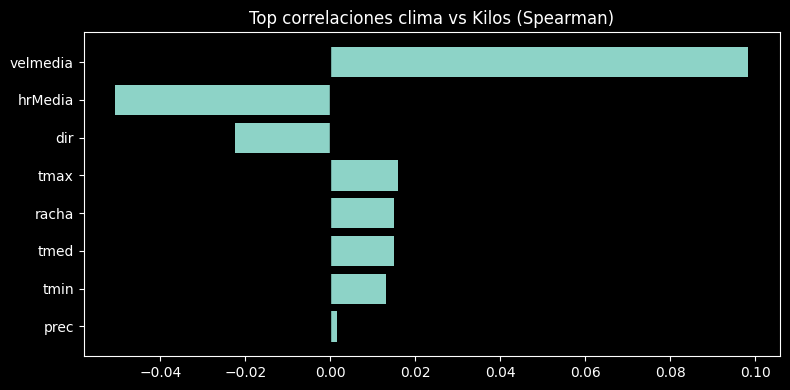

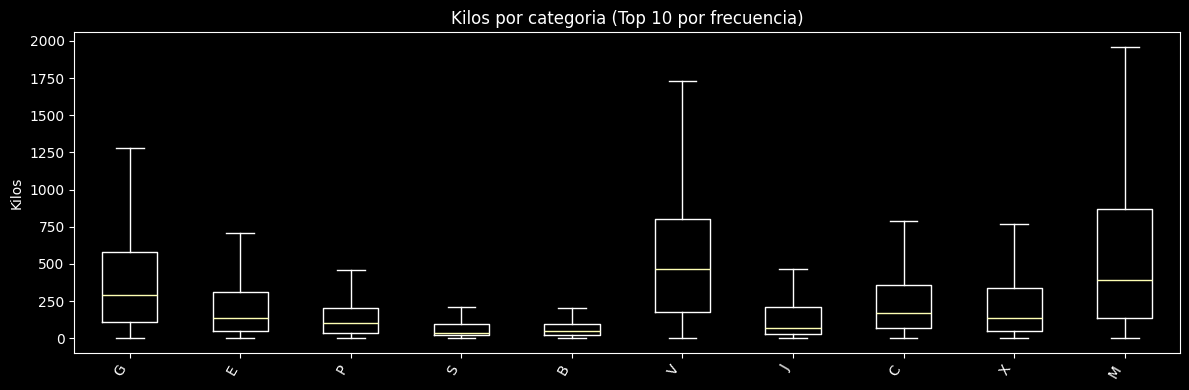

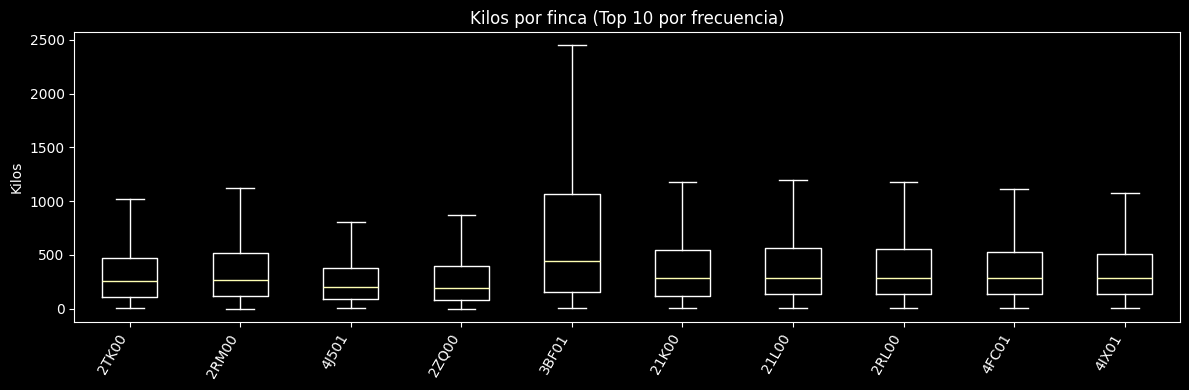

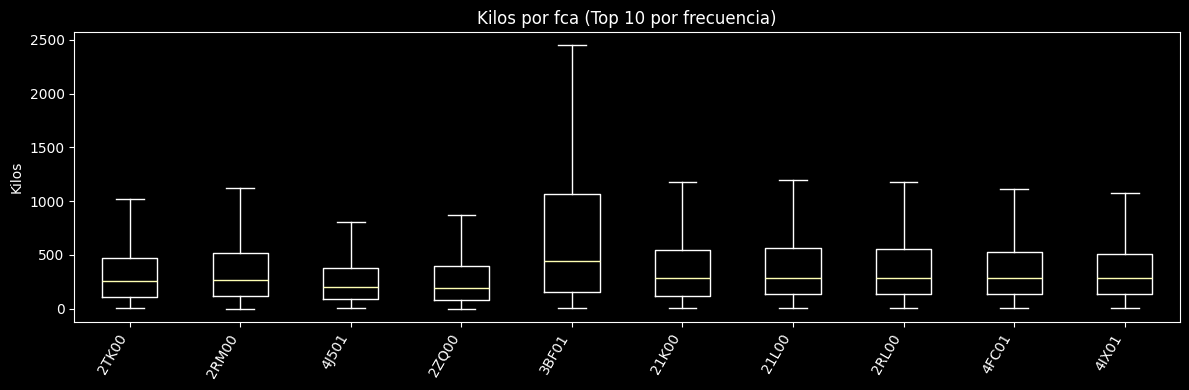

**Tests categórica vs Kilos**

,variable,test,p_value,effect_size,note
0,categoria,Kruskal-Wallis,0.0,0.188229,"k=10, n=1498870"
1,finca,Kruskal-Wallis,0.0,0.030624,"k=10, n=139408"
2,fca,Kruskal-Wallis,0.0,0.030624,"k=10, n=139408"


Correlación Pearson (tendencia temporal vs Kilos): r=-0.0261, p=1.1194e-224
Correlación Spearman (Semana_num vs Kilos): rho=0.0011, p=1.8888e-01


**Correlación semanal clima vs Kilos**

,rho_semana
tmax,-0.190340
tmed,-0.172722
prec,0.168697
tmin,-0.149660
velmedia,0.122141
hrMedia,-0.086844
racha,0.031492
dir,-0.012779


<Figure size 1000x400 with 0 Axes>

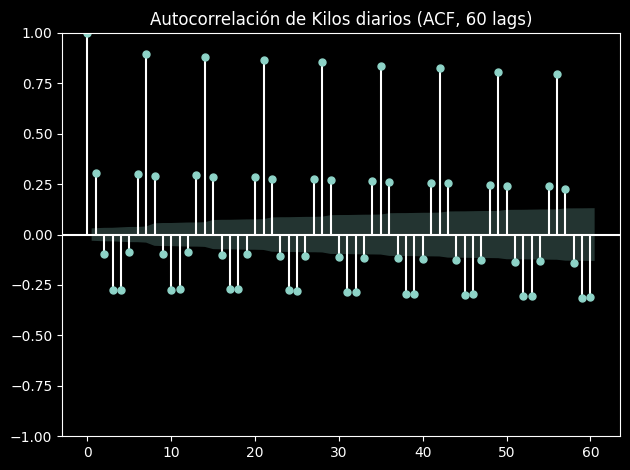

In [5]:

if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    climate_cols = [c for c in CLIMATE_COLS if c in df.columns]

    corr_cols = [c for c in [COL_TARGET, COL_AREA, "pescaj", COL_WEEK_NUM] if c is not None and c in df.columns]
    corr_cols += [c for c in climate_cols if c not in corr_cols]
    corr_cols += [c for c in ["ratio_kilos_m2"] if c in df.columns and c not in corr_cols]

    if len(corr_cols) >= 2:
        corr = df[corr_cols].corr(method="spearman")
        display_df(corr, "Matriz de correlación (Spearman)", len(corr))

        fig, ax = plt.subplots(figsize=(10, 7))
        im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_cols)))
        ax.set_xticklabels(corr_cols, rotation=45, ha="right")
        ax.set_yticks(range(len(corr_cols)))
        ax.set_yticklabels(corr_cols)
        ax.set_title("Heatmap correlación (numéricas + clima)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    if climate_cols and COL_TARGET in df.columns:
        climate_corr_rows = []
        for col in climate_cols:
            tmp = df[[COL_TARGET, col]].copy()
            tmp[COL_TARGET] = pd.to_numeric(tmp[COL_TARGET], errors="coerce")
            tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
            tmp = tmp.dropna()
            if len(tmp) >= 30:
                rho = tmp.corr(method="spearman").loc[COL_TARGET, col]
                climate_corr_rows.append({"variable_clima": col, "spearman_rho": float(rho), "n": int(len(tmp))})

        if climate_corr_rows:
            climate_corr_df = pd.DataFrame(climate_corr_rows)
            climate_corr_df["abs_rho"] = climate_corr_df["spearman_rho"].abs()
            climate_corr_df = climate_corr_df.sort_values("abs_rho", ascending=False)
            display_df(climate_corr_df.drop(columns=["abs_rho"]), "Correlación clima vs Kilos", len(climate_corr_df))

            top_plot = climate_corr_df.head(8).iloc[::-1]
            plt.figure(figsize=(8, 4))
            plt.barh(top_plot["variable_clima"], top_plot["spearman_rho"])
            plt.axvline(0, color="black", linewidth=1)
            plt.title("Top correlaciones clima vs Kilos (Spearman)")
            plt.tight_layout()
            plt.show()

    cat_for_box = [c for c in [COL_CATEGORY, "patron", COL_FARM, COL_FCA, "Orden", "producto"] if c is not None and c in df.columns]
    for col in cat_for_box:
        tmp = df.dropna(subset=[col, COL_TARGET]).copy()
        if tmp.empty:
            continue
        top_vals = tmp[col].value_counts().head(10).index
        tmp = tmp[tmp[col].isin(top_vals)]
        if tmp.empty:
            continue
        groups = [tmp.loc[tmp[col] == v, COL_TARGET].values for v in top_vals]
        plt.figure(figsize=(12, 4))
        plt.boxplot(groups, labels=[str(v) for v in top_vals], showfliers=False)
        plt.title(f"Kilos por {col} (Top 10 por frecuencia)")
        plt.xticks(rotation=60, ha="right")
        plt.ylabel(COL_TARGET)
        plt.tight_layout()
        plt.show()

    def group_test(target_df: pd.DataFrame, group_col: str, target_col: str = COL_TARGET, top_n: int = 10, min_group: int = 30):
        if not SCIPY_AVAILABLE:
            return {
                "variable": group_col,
                "test": "N/A",
                "p_value": np.nan,
                "effect_size": np.nan,
                "note": "scipy no disponible",
            }

        tmp = target_df.dropna(subset=[group_col, target_col]).copy()
        if tmp.empty:
            return None

        top_vals = tmp[group_col].value_counts().head(top_n).index
        tmp = tmp[tmp[group_col].isin(top_vals)]

        groups = [g[target_col].values for _, g in tmp.groupby(group_col)]
        groups = [g for g in groups if len(g) >= min_group]
        if len(groups) < 2:
            return {
                "variable": group_col,
                "test": "N/A",
                "p_value": np.nan,
                "effect_size": np.nan,
                "note": "grupos insuficientes",
            }

        normal_flags = []
        for g in groups:
            sample = g if len(g) <= 5000 else np.random.RandomState(SEED).choice(g, 5000, replace=False)
            if len(sample) >= 20:
                p_norm = stats.normaltest(sample).pvalue
                normal_flags.append(p_norm > 0.05)
            else:
                normal_flags.append(False)

        p_levene = stats.levene(*groups).pvalue if len(groups) >= 2 else 0.0
        use_anova = all(normal_flags) and (p_levene > 0.05)

        all_vals = np.concatenate(groups)
        k = len(groups)
        n = len(all_vals)

        if use_anova:
            f_stat, p_val = stats.f_oneway(*groups)
            grand_mean = np.mean(all_vals)
            ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
            ss_total = np.sum((all_vals - grand_mean) ** 2)
            eta_sq = ss_between / ss_total if ss_total > 0 else np.nan
            return {
                "variable": group_col,
                "test": "ANOVA",
                "p_value": p_val,
                "effect_size": eta_sq,
                "note": f"k={k}, n={n}",
            }
        else:
            h_stat, p_val = stats.kruskal(*groups)
            eps_sq = (h_stat - k + 1) / (n - k) if n > k else np.nan
            return {
                "variable": group_col,
                "test": "Kruskal-Wallis",
                "p_value": p_val,
                "effect_size": eps_sq,
                "note": f"k={k}, n={n}",
            }

    test_vars = [c for c in [COL_CATEGORY, "patron", COL_FARM, COL_FCA, "Orden", "producto"] if c is not None and c in df.columns]
    test_results = []
    for c in test_vars:
        res = group_test(df, c)
        if res is not None:
            test_results.append(res)

    if test_results:
        tests_df = pd.DataFrame(test_results).sort_values("p_value", na_position="last")
        display_df(tests_df, "Tests categórica vs Kilos", len(tests_df))

    if COL_DATE in df.columns and COL_TARGET in df.columns:
        tdf = df.dropna(subset=[COL_DATE, COL_TARGET]).copy()
        if not tdf.empty:
            tdf = tdf.sort_values(COL_DATE)
            t0 = tdf[COL_DATE].min()
            tdf["time_index_days"] = (tdf[COL_DATE] - t0).dt.total_seconds() / 86400.0

            if SCIPY_AVAILABLE:
                pearson_trend = stats.pearsonr(tdf["time_index_days"], tdf[COL_TARGET])
                print(f"Correlación Pearson (tendencia temporal vs Kilos): r={pearson_trend.statistic:.4f}, p={pearson_trend.pvalue:.4e}")
                if COL_WEEK_NUM in tdf.columns:
                    tmp = tdf.dropna(subset=[COL_WEEK_NUM])
                    if not tmp.empty:
                        sp = stats.spearmanr(tmp[COL_WEEK_NUM], tmp[COL_TARGET])
                        print(f"Correlación Spearman (Semana_num vs Kilos): rho={sp.statistic:.4f}, p={sp.pvalue:.4e}")

            if climate_cols:
                weekly = tdf.set_index(COL_DATE).resample("W-MON")[[COL_TARGET]].sum()
                clim_tmp = tdf[[COL_DATE] + climate_cols].copy()
                for c in climate_cols:
                    clim_tmp[c] = pd.to_numeric(clim_tmp[c], errors="coerce")
                weekly_clim = clim_tmp.set_index(COL_DATE).resample("W-MON")[climate_cols].mean()
                weekly_all = weekly.join(weekly_clim, how="inner").dropna()
                if len(weekly_all) >= 20:
                    wcorr = weekly_all.corr(method="spearman")[[COL_TARGET]].drop(index=[COL_TARGET], errors="ignore")
                    wcorr = wcorr.sort_values(COL_TARGET, key=lambda s: s.abs(), ascending=False)
                    display_df(wcorr.rename(columns={COL_TARGET: "rho_semana"}), "Correlación semanal clima vs Kilos", len(wcorr))

            if STATSMODELS_AVAILABLE:
                daily = tdf.set_index(COL_DATE).resample("D")[COL_TARGET].sum().fillna(0)
                plt.figure(figsize=(10, 4))
                plot_acf(daily, lags=60)
                plt.title("Autocorrelación de Kilos diarios (ACF, 60 lags)")
                plt.tight_layout()
                plt.show()




## 5) Preparación de features (pre-modelado)
- Ingeniería básica de fecha, ratios y variables climáticas.
- Separación numéricas/categóricas.
- Imputación y escalado.
- OneHot en categóricas.
- Alta cardinalidad: compresión Top-K + `OTHER`.
- Exclusión recomendada de IDs.


In [6]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    model_df = df.copy()

    if COL_DATE in model_df.columns:
        model_df["year"] = model_df[COL_DATE].dt.year
        model_df["month"] = model_df[COL_DATE].dt.month
        model_df["day"] = model_df[COL_DATE].dt.day
        model_df["dayofweek"] = model_df[COL_DATE].dt.dayofweek

    target_col = COL_TARGET
    climate_cols = [c for c in CLIMATE_COLS if c in model_df.columns]
    known_id_cols = [c for c in ["RegLin", "Albaran", "AlbLin", "Orden"] if c in model_df.columns]
    n_rows = len(model_df)
    auto_id_like = [
        c
        for c in model_df.columns
        if c not in climate_cols
        and model_df[c].dtype == "object"
        and (model_df[c].nunique(dropna=False) / max(1, n_rows)) >= 0.98
    ]

    drop_recommended = sorted(set(known_id_cols + auto_id_like))

    candidate_features = [c for c in model_df.columns if c != target_col and c not in drop_recommended]
    if COL_DATE in candidate_features:
        candidate_features.remove(COL_DATE)  # Se usan sus derivados

    model_ready = model_df.dropna(subset=[target_col]).copy()

    X_base = model_ready[candidate_features].copy()
    y_base = model_ready[target_col].astype(float)

    cat_cols = [c for c in X_base.columns if X_base[c].dtype == "object"]
    num_cols = [c for c in X_base.columns if c not in cat_cols]

    high_card_cols = [c for c in cat_cols if X_base[c].nunique(dropna=True) > 50]

    def top_k_other(series: pd.Series, k: int = 30) -> pd.Series:
        s = series.fillna("missing").astype(str)
        top = set(s.value_counts().head(k).index)
        return s.where(s.isin(top), "OTHER")

    X = X_base.copy()
    for c in high_card_cols:
        X[c] = top_k_other(X[c], k=30)

    cat_cols_final = [c for c in X.columns if X[c].dtype == "object"]
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols_final),
        ("cat", categorical_transformer, cat_cols_final),
    ])

    print("Filas para modelado:", len(X))
    print("Numéricas:", num_cols_final)
    print("Categóricas:", cat_cols_final)
    print("Alta cardinalidad (Top-K + OTHER):", high_card_cols)
    print("Climáticas detectadas:", climate_cols)
    print("Columnas recomendadas para excluir por comportamiento de ID:", drop_recommended)

    id_example_text = ", ".join(known_id_cols) if known_id_cols else "IDs transaccionales"
    display(Markdown(
        f"**Recomendación:** excluir columnas tipo ID (por ejemplo `{id_example_text}`) "
        "porque capturan identidad transaccional y no generalizan bien en predicción."
    ))




Filas para modelado: 1503209
Numéricas: ['M2', 'tmed', 'tmin', 'tmax', 'prec', 'hrMedia', 'velmedia', 'dir', 'racha', 'altitud', 'Semana_num', 'ratio_kilos_m2', 'year', 'month', 'day', 'dayofweek']
Categóricas: ['instant', 'fca', 'Category', 'Production', 'Area', 'Territory.Temperature:Average', 'Territory.Temperature:Min', 'Territory.Temperature:Max', 'Territory.Precipitation', 'Territory.Humidity', 'Territory.WindSpeed:Average', 'Territory.WindDirection', 'Territory.WindSpeed:Max', 'Altitude', 'Island', 'categoria', 'isla', 'finca', 'Semana']
Alta cardinalidad (Top-K + OTHER): ['instant', 'fca', 'Production', 'Area', 'Territory.Temperature:Average', 'Territory.Temperature:Min', 'Territory.Temperature:Max', 'Territory.Precipitation', 'Territory.Humidity', 'Territory.WindSpeed:Average', 'Territory.WindSpeed:Max', 'Altitude', 'finca', 'Semana']
Climáticas detectadas: ['tmed', 'tmin', 'tmax', 'prec', 'hrMedia', 'velmedia', 'dir', 'racha']
Columnas recomendadas para excluir por comportami

**Recomendación:** excluir columnas tipo ID (por ejemplo `IDs transaccionales`) porque capturan identidad transaccional y no generalizan bien en predicción.

## 6) Relevancia de variables para predecir `Kilos`
Baselines rápidos y explicables:
- `mutual_info_regression`
- `RandomForestRegressor`
- `permutation_importance`

> Se usa muestreo para mantener tiempo/memoria razonables.


**Top mutual information**

,feature,mi
11,num__ratio_kilos_m2,6.675560
123,cat__Production_OTHER,0.688664
99,cat__Production_17.000,0.194746
0,num__M2,0.189371
112,cat__Production_34.000,0.175277
83,cat__Category_G,0.163214
449,cat__categoria_G,0.163214
12,num__year,0.152637
118,cat__Production_51.000,0.148957
88,cat__Category_S,0.131612


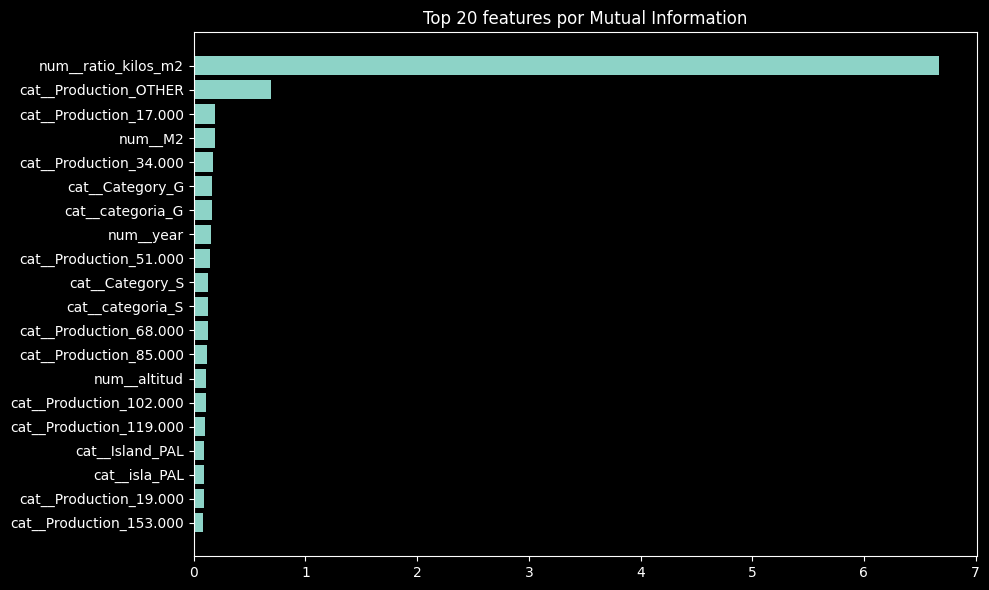

RandomForest - MAE: 120.8994 | RMSE: 323.0378 | R2: 0.6573


**Top importancia RF**

,feature,importance
11,num__ratio_kilos_m2,0.310697
0,num__M2,0.103482
123,cat__Production_OTHER,0.071353
449,cat__categoria_G,0.028809
442,cat__Island_PAL,0.025708
460,cat__isla_PAL,0.024595
12,num__year,0.023916
83,cat__Category_G,0.023395
443,cat__Island_TEN,0.023350
461,cat__isla_TEN,0.019555


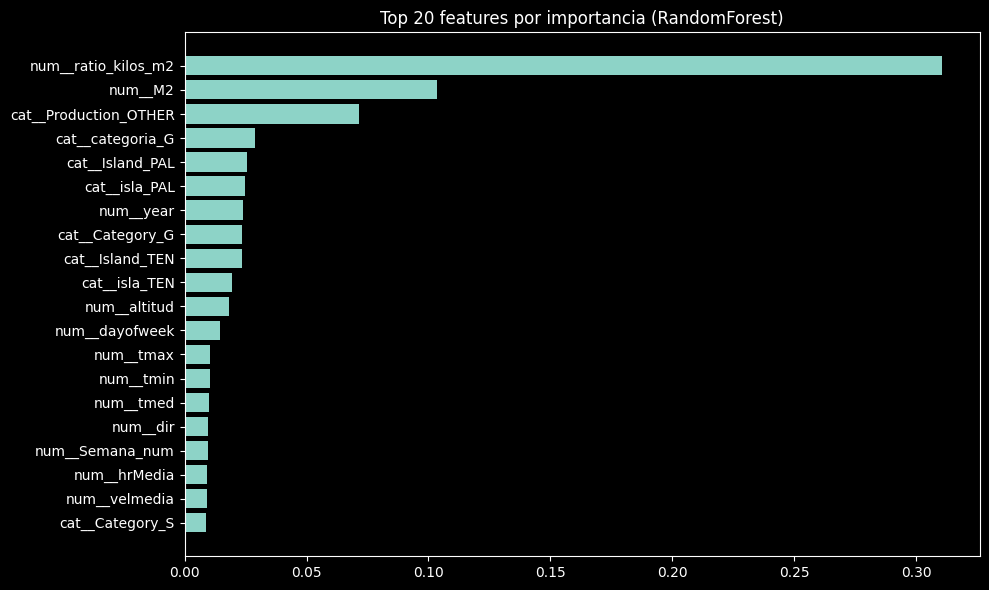

KeyboardInterrupt: 

In [7]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    MAX_MODEL_ROWS = 120_000

    if len(X) > MAX_MODEL_ROWS:
        X_model = X.sample(MAX_MODEL_ROWS, random_state=SEED)
        y_model = y_base.loc[X_model.index]
    else:
        X_model = X.copy()
        y_model = y_base.copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X_model, y_model, test_size=0.2, random_state=SEED
    )

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()

    # 1) Mutual information
    mi_scores = None
    try:
        mi_scores = mutual_info_regression(X_train_t, y_train, random_state=SEED)
    except Exception as exc:
        print(f"[WARN] mutual_info_regression falló sobre matriz transformada: {exc}")

    if mi_scores is not None:
        mi_df = pd.DataFrame({"feature": feature_names, "mi": mi_scores}).sort_values("mi", ascending=False)
        display_df(mi_df, "Top mutual information", 20)

        top_mi = mi_df.head(20).iloc[::-1]
        plt.figure(figsize=(10, 6))
        plt.barh(top_mi["feature"], top_mi["mi"])
        plt.title("Top 20 features por Mutual Information")
        plt.tight_layout()
        plt.show()

    # 2) Random forest
    rf = RandomForestRegressor(
        n_estimators=250,
        random_state=SEED,
        n_jobs=-1,
        min_samples_leaf=5,
        max_features="sqrt",
    )
    rf.fit(X_train_t, y_train)

    pred = rf.predict(X_test_t)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"RandomForest - MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)
    display_df(imp_df, "Top importancia RF", 20)

    top_imp = imp_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(top_imp["feature"], top_imp["importance"])
    plt.title("Top 20 features por importancia (RandomForest)")
    plt.tight_layout()
    plt.show()

    # 3) Permutation importance
    perm_n = min(20_000, X_test_t.shape[0])
    rs = np.random.RandomState(SEED)
    perm_idx = rs.choice(X_test_t.shape[0], size=perm_n, replace=False)

    X_perm = X_test_t[perm_idx]
    if hasattr(X_perm, "toarray"):
        X_perm = X_perm.toarray()

    perm_result = permutation_importance(
        rf,
        X_perm,
        y_test.iloc[perm_idx],
        n_repeats=5,
        random_state=SEED,
        n_jobs=-1,
    )

    perm_df = pd.DataFrame({
        "feature": feature_names,
        "perm_importance": perm_result.importances_mean,
    }).sort_values("perm_importance", ascending=False)
    display_df(perm_df, "Top permutation importance", 20)

    top_perm = perm_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(top_perm["feature"], top_perm["perm_importance"])
    plt.title("Top 20 features por permutation importance")
    plt.tight_layout()
    plt.show()

    top_features_union = set(imp_df.head(20)["feature"]).union(set(perm_df.head(20)["feature"]))
    print("Variables potencialmente más influyentes (Top RF ∪ Top Permutation):")
    for feat in sorted(top_features_union):
        print(" -", feat)



In [ ]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    base = df.copy()
    if COL_DATE not in base.columns or COL_TARGET not in base.columns:
        print("Faltan columnas requeridas ('Fecha' y/o 'Kilos').")
    else:
        base[COL_DATE] = pd.to_datetime(base[COL_DATE], errors="coerce")
        base[COL_TARGET] = pd.to_numeric(base[COL_TARGET], errors="coerce")
        climate_cols = [c for c in CLIMATE_COLS if c in base.columns]
        for c in climate_cols:
            base[c] = pd.to_numeric(base[c], errors="coerce")
        base = base.dropna(subset=[COL_DATE, COL_TARGET]).sort_values(COL_DATE)

        def detect_changepoints_series(series: pd.Series, window: int = 8, z_th: float = 3.5) -> pd.DataFrame:
            s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
            if s.shape[0] < max(20, window * 2):
                return pd.DataFrame(columns=[COL_DATE, "value", "score"])
            minp = max(3, window // 2)
            med = s.rolling(window=window, min_periods=minp).median()
            mad = (s - med).abs().rolling(window=window, min_periods=minp).median()
            scale = (1.4826 * mad).replace(0, np.nan)
            score = ((s - med) / scale).replace([np.inf, -np.inf], np.nan)
            out = pd.DataFrame({
                COL_DATE: s.index,
                "value": s.values,
                "score": score.values,
            }).dropna(subset=["score"])
            out = out[out["score"].abs() >= z_th]
            out = out.sort_values("score", key=lambda col: col.abs(), ascending=False)
            return out

        print("[1] Changepoints")
        weekly = base.set_index(COL_DATE)[COL_TARGET].resample("W-MON").sum().sort_index()
        cp_global = detect_changepoints_series(weekly, window=8, z_th=3.5)
        if cp_global.empty:
            print("No se detectaron changepoints robustos a nivel global con el umbral actual.")
        else:
            cp_show = cp_global.rename(columns={"value": "kilos_semana", "score": "z_robusto"})
            display_df(cp_show, "Top changepoints globales", 15)

        plt.figure(figsize=(12, 4))
        plt.plot(weekly.index, weekly.values, label="Kilos semanales", linewidth=1.2)
        if not cp_global.empty:
            top_cp = cp_global.head(20)
            plt.scatter(top_cp[COL_DATE], top_cp["value"], color="red", s=25, label="Changepoints")
        plt.title("Serie semanal de Kilos y changepoints")
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

        stl_cls = globals().get("STL", None)
        if globals().get("STATSMODELS_AVAILABLE", False) and stl_cls is not None and weekly.shape[0] >= 104:
            stl_fit = stl_cls(weekly.asfreq("W-MON").fillna(0), period=52, robust=True).fit()
            plt.figure(figsize=(12, 6))
            plt.subplot(3, 1, 1)
            plt.plot(stl_fit.trend.index, stl_fit.trend.values)
            plt.title("STL - Tendencia")
            plt.subplot(3, 1, 2)
            plt.plot(stl_fit.seasonal.index, stl_fit.seasonal.values)
            plt.title("STL - Estacionalidad")
            plt.subplot(3, 1, 3)
            plt.plot(stl_fit.resid.index, stl_fit.resid.values)
            plt.title("STL - Residuo")
            plt.tight_layout()
            plt.show()

        if COL_FARM is not None and COL_FARM in base.columns:
            finca_cp_frames = []
            top_fincas = base.groupby(COL_FARM)[COL_TARGET].sum().sort_values(ascending=False).head(5).index.tolist()
            for finca_val in top_fincas:
                serie_f = base.loc[base[COL_FARM] == finca_val].set_index(COL_DATE)[COL_TARGET].resample("W-MON").sum().sort_index()
                cp_f = detect_changepoints_series(serie_f, window=8, z_th=3.5)
                if not cp_f.empty:
                    cp_f[COL_FARM] = str(finca_val)
                    finca_cp_frames.append(cp_f)
            if finca_cp_frames:
                cp_finca = pd.concat(finca_cp_frames, ignore_index=True)
                cp_finca = cp_finca.rename(columns={"value": "kilos_semana", "score": "z_robusto"})
                cp_finca = cp_finca[[COL_FARM, COL_DATE, "kilos_semana", "z_robusto"]]
                cp_finca = cp_finca.sort_values("z_robusto", key=lambda col: col.abs(), ascending=False)
                display_df(cp_finca, "Changepoints en top fincas por volumen", 20)

        print("\n[2] Eficiencia ajustada (residuos tras controlar contexto)")
        eff_needed = {c for c in [COL_TARGET, COL_AREA, COL_DATE] if c is not None}
        if not eff_needed.issubset(base.columns):
            print("No se puede estimar eficiencia ajustada: faltan columnas numéricas base.")
        else:
            eff_cols = [c for c in [COL_TARGET, COL_AREA, COL_CATEGORY, "patron", "producto", COL_FARM, COL_DATE] if c in base.columns] + climate_cols
            eff = base[eff_cols].copy()
            eff[COL_AREA] = pd.to_numeric(eff[COL_AREA], errors="coerce")
            required_eff = [COL_TARGET, COL_AREA, COL_DATE]
            eff = eff.dropna(subset=required_eff)
            eff = eff[(eff[COL_AREA] >= 0)]
            context_group_cols = [c for c in [COL_CATEGORY, "patron", "producto", COL_FARM] if c in eff.columns]
            for cat_col in context_group_cols:
                eff[cat_col] = eff[cat_col].fillna("missing").astype(str)
            if len(eff) > 180_000:
                eff = eff.sample(180_000, random_state=SEED)
            for col_name, top_k in [("patron", 40), ("producto", 40), (COL_FARM, 80)]:
                if col_name in eff.columns:
                    top_vals = set(eff[col_name].value_counts().head(top_k).index)
                    eff[col_name] = np.where(eff[col_name].isin(top_vals), eff[col_name], "OTHER")
            eff["year"] = eff[COL_DATE].dt.year.astype("Int64").astype(str)
            eff["month"] = eff[COL_DATE].dt.month.astype("Int64").astype(str)
            eff["log_kilos"] = np.log1p(eff[COL_TARGET].clip(lower=0))
            eff["log_m2"] = np.log1p(eff[COL_AREA].clip(lower=0))

            if STATSMODELS_AVAILABLE and smf is not None:
                predictor_cats = [c for c in [COL_CATEGORY, "patron", "producto"] if c in eff.columns]
                climate_predictors = [c for c in climate_cols if c in eff.columns]
                formula_terms = ["log_m2"] + climate_predictors + [f"C({c})" for c in predictor_cats] + ["C(month)", "C(year)"]
                eff_formula = "log_kilos ~ " + " + ".join(formula_terms)
                eff_fit = smf.ols(formula=eff_formula, data=eff).fit()
                eff["resid_eff"] = eff_fit.resid
                if COL_FARM in eff.columns:
                    finca_eff = eff.groupby(COL_FARM)["resid_eff"].agg(["count", "mean", "median", "std"]).reset_index()
                    finca_eff = finca_eff[finca_eff["count"] >= 30].sort_values("mean", ascending=False)
                    display_df(finca_eff, "Ranking de eficiencia ajustada por finca (residuo medio)", 20)
                    if not finca_eff.empty:
                        top10 = finca_eff.head(10).iloc[::-1]
                        bot10 = finca_eff.tail(10)
                        plt.figure(figsize=(12, 5))
                        plt.subplot(1, 2, 1)
                        plt.barh(top10[COL_FARM], top10["mean"])
                        plt.title("Top 10 sobre-rendimiento")
                        plt.subplot(1, 2, 2)
                        plt.barh(bot10[COL_FARM], bot10["mean"])
                        plt.title("Top 10 infra-rendimiento")
                        plt.tight_layout()
                        plt.show()
                else:
                    print("Columna 'finca' no disponible; se omite ranking de eficiencia por finca.")
                print(f"R2 ajustado del modelo de eficiencia: {eff_fit.rsquared_adj:.4f}")
            else:
                print("statsmodels no disponible para eficiencia ajustada.")

        print("\n[3] Efectos mixtos por finca")
        panel_needed = {c for c in [COL_TARGET, COL_AREA, COL_DATE, COL_FARM] if c is not None}
        if not panel_needed.issubset(base.columns):
            print("No se puede ajustar MixedLM: faltan columnas clave.")
        elif not (STATSMODELS_AVAILABLE and smf is not None):
            print("statsmodels no disponible para MixedLM.")
        else:
            panel_cols = [c for c in [COL_TARGET, COL_AREA, COL_DATE, COL_FARM, COL_CATEGORY] if c in base.columns] + climate_cols
            panel = base[panel_cols].copy()
            panel[COL_AREA] = pd.to_numeric(panel[COL_AREA], errors="coerce")
            required_panel = [COL_TARGET, COL_AREA, COL_DATE, COL_FARM]
            panel = panel.dropna(subset=required_panel)
            panel = panel[(panel[COL_AREA] >= 0)]
            panel[COL_FARM] = panel[COL_FARM].astype(str)
            if COL_CATEGORY not in panel.columns:
                panel[COL_CATEGORY] = "missing"
            panel[COL_CATEGORY] = panel[COL_CATEGORY].fillna("missing").astype(str)
            keep_fincas = panel[COL_FARM].value_counts()
            keep_fincas = keep_fincas[keep_fincas >= 25].head(120).index
            panel = panel[panel[COL_FARM].isin(keep_fincas)]
            if len(panel) > 80_000:
                panel = panel.sample(80_000, random_state=SEED)
            if panel[COL_FARM].nunique() < 5:
                print("No hay suficiente variedad de fincas para MixedLM.")
            else:
                panel["log_kilos"] = np.log1p(panel[COL_TARGET].clip(lower=0))
                panel["log_m2"] = np.log1p(panel[COL_AREA].clip(lower=0))
                panel["month"] = panel[COL_DATE].dt.month.astype("Int64").astype(str)
                panel["year"] = panel[COL_DATE].dt.year.astype("Int64").astype(str)
                mix_climate_terms = [c for c in climate_cols if c in panel.columns]
                base_terms = ["log_m2"]
                mix_formula = "log_kilos ~ " + " + ".join(base_terms) + (" + " + " + ".join(mix_climate_terms) if mix_climate_terms else "") + f" + C({COL_CATEGORY}) + C(month) + C(year)"
                try:
                    mix_model = smf.mixedlm(mix_formula, data=panel, groups=panel[COL_FARM])
                    mix_fit = mix_model.fit(reml=False, method="lbfgs", maxiter=200, disp=False)
                    print(f"MixedLM convergió. LogLik={mix_fit.llf:.2f} | AIC={mix_fit.aic:.2f}")
                    fixed_head = mix_fit.fe_params.sort_values(key=lambda col: col.abs(), ascending=False).head(12)
                    display_df(fixed_head.to_frame(name="coef"), "Coeficientes fijos (|coef| top)", 12)
                    re_items = []
                    for finca_key, re_val in mix_fit.random_effects.items():
                        arr = np.asarray(re_val).astype(float).ravel()
                        if arr.size > 0:
                            re_items.append((str(finca_key), float(arr[0])))
                    re_df = pd.DataFrame(re_items, columns=[COL_FARM, "finca_effect"]).sort_values("finca_effect", ascending=False)
                    display_df(re_df, "Efecto aleatorio por finca", 20)
                except Exception as exc:
                    print(f"[WARN] MixedLM no convergió o no fue estable: {exc}")

        print("\n[4] Anomalías en residuos con baseline OOF")
        if "X" not in globals() or "y_base" not in globals() or "preprocessor" not in globals():
            print("No se encontró el bloque de pre-modelado (sección 5).")
        else:
            X_anom = X.copy()
            y_anom = y_base.copy()
            if len(X_anom) > 40_000:
                sample_idx = y_anom.sample(40_000, random_state=SEED).index
                X_anom = X_anom.loc[sample_idx]
                y_anom = y_anom.loc[sample_idx]
            else:
                sample_idx = X_anom.index

            meta_cols = [c for c in [COL_DATE, COL_FARM, "producto", COL_CATEGORY, "patron"] if c in model_ready.columns]
            if meta_cols:
                meta = model_ready.loc[sample_idx, meta_cols].copy().reset_index(drop=True)
            else:
                meta = pd.DataFrame(index=range(len(sample_idx)))

            X_anom = X_anom.reset_index(drop=True)
            y_anom = y_anom.reset_index(drop=True)

            kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
            oof_pred = np.full(shape=len(X_anom), fill_value=np.nan, dtype=float)

            for fold_id, (tr_idx, te_idx) in enumerate(kf.split(X_anom), start=1):
                X_tr = X_anom.iloc[tr_idx]
                X_te = X_anom.iloc[te_idx]
                y_tr = y_anom.iloc[tr_idx]

                X_tr_t = preprocessor.fit_transform(X_tr)
                X_te_t = preprocessor.transform(X_te)

                fold_model = RandomForestRegressor(
                    n_estimators=120,
                    random_state=SEED + fold_id,
                    n_jobs=-1,
                    min_samples_leaf=5,
                    max_features="sqrt",
                )
                fold_model.fit(X_tr_t, y_tr)
                oof_pred[te_idx] = fold_model.predict(X_te_t)

            valid_mask = ~np.isnan(oof_pred)
            if valid_mask.sum() == 0:
                print("No se pudieron calcular predicciones OOF.")
            else:
                y_val = y_anom.loc[valid_mask].to_numpy(dtype=float)
                p_val = oof_pred[valid_mask]
                resid = y_val - p_val
                resid_med = np.nanmedian(resid)
                resid_mad = np.nanmedian(np.abs(resid - resid_med))
                resid_scale = 1.4826 * resid_mad
                if not np.isfinite(resid_scale) or resid_scale <= 0:
                    resid_scale = np.nanstd(resid)
                z_rob = (resid - resid_med) / (resid_scale if resid_scale > 0 else 1.0)

                anom = pd.DataFrame({
                    COL_TARGET: y_val,
                    "pred_oof": p_val,
                    "residual": resid,
                    "z_robusto": z_rob,
                })
                meta_valid = meta.loc[valid_mask].reset_index(drop=True)
                anom = pd.concat([meta_valid, anom], axis=1)
                anom = anom.sort_values("z_robusto", key=lambda col: col.abs(), ascending=False)
                display_df(anom, "Top anomalías por residuo absoluto robusto", 25)

                mae_oof = mean_absolute_error(y_val, p_val)
                rmse_oof = np.sqrt(mean_squared_error(y_val, p_val))
                print(f"OOF baseline - MAE: {mae_oof:.4f} | RMSE: {rmse_oof:.4f}")

                plt.figure(figsize=(10, 4))
                plt.hist(resid, bins=70)
                plt.title("Distribución de residuos OOF")
                plt.tight_layout()
                plt.show()





## 8) Dependencia temporal de `Kilos` (20 lags) y predicción a 90 días
Objetivo de esta sección:
- medir correlación entre `Kilos(t), Kilos(t-1), ..., Kilos(t-19)` y `Kilos(t+90)`,
- entrenar un modelo temporal usando esos 20 valores previos,
- estimar una predicción puntual para la fecha `última_fecha + 90 días`.

**Correlación de cada lag (0..19) vs Kilos +90d**

,lag_dias,pearson,spearman
0,0,0.201143,0.260175
1,1,0.748922,0.770091
2,2,0.190874,0.249008
3,3,-0.183799,-0.225295
4,4,-0.349733,-0.428855
5,5,-0.344989,-0.420467
6,6,-0.166608,-0.201899
7,7,0.193066,0.254521
8,8,0.738954,0.762709
9,9,0.183956,0.244841


Lag con mayor |Spearman| vs +90d: lag_01 (Spearman=+0.7701, Pearson=+0.7489)


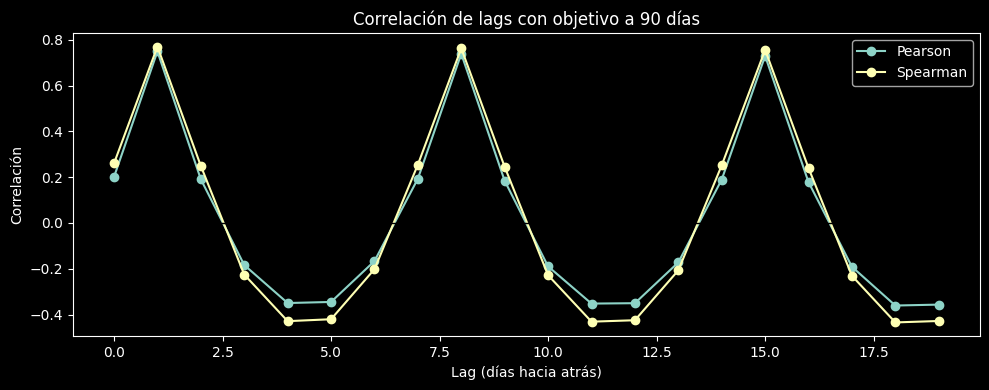

**Rendimiento en test temporal (objetivo +90 días)**

,modelo,MAE,RMSE,R2,n_test
0,RandomForest (lags 0..19),42844.968548,62108.228109,0.748789,795
1,Baseline persistencia (lag_00),105116.969547,156644.828626,-0.597982,795


**Importancia de cada lag para predecir +90d**

,feature,importance
1,lag_01,0.163481
8,lag_08,0.140256
15,lag_15,0.138264
10,lag_10,0.070038
3,lag_03,0.063769
17,lag_17,0.060683
12,lag_12,0.034222
5,lag_05,0.033451
19,lag_19,0.029222
9,lag_09,0.028650


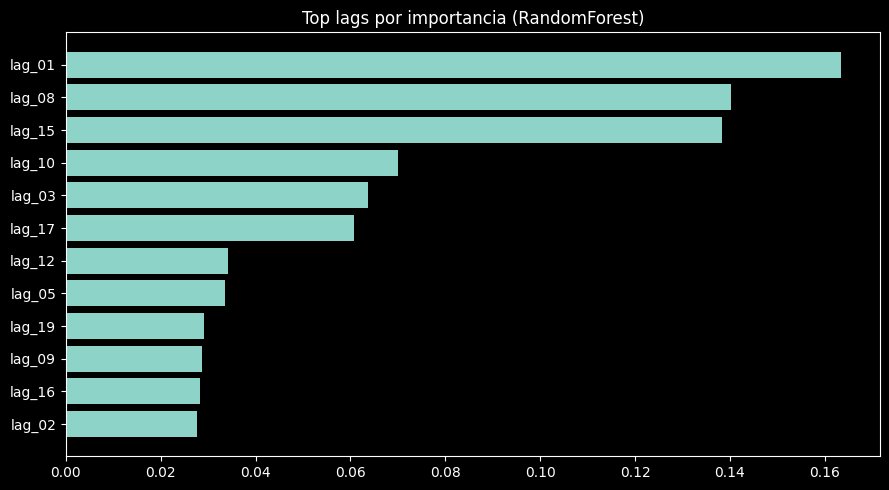

Tendencia lineal en los últimos 20 días: descendente (pendiente=-821.666 kilos/día)
Predicción puntual para 2026-05-28 (horizonte +90 días): 150,623.70 kilos


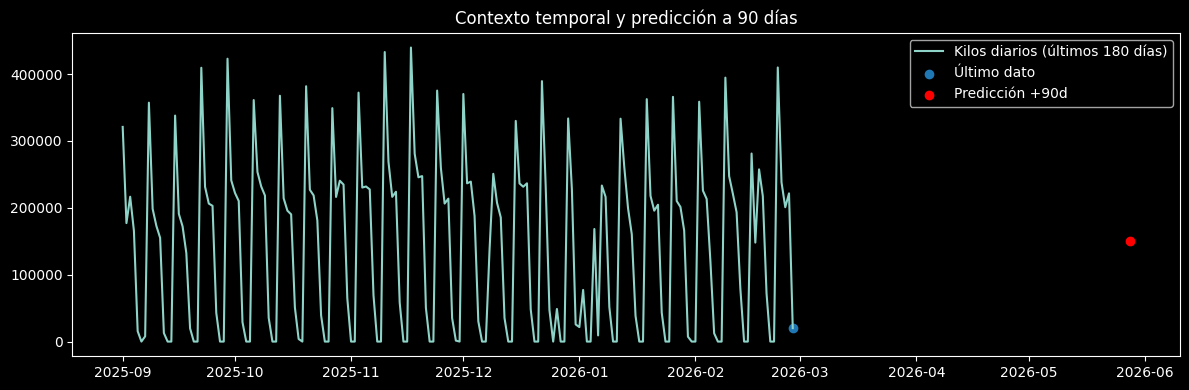

In [8]:
if not DATA_AVAILABLE:
    print("Dataset no disponible. Se omite sección.")
else:
    if COL_DATE not in df.columns or COL_TARGET not in df.columns:
        print("Faltan columnas requeridas ('Fecha' y/o 'Kilos').")
    else:
        horizon_days = 90
        lag_window = 20

        ts_lag = (
            df[[COL_DATE, COL_TARGET]]
            .copy()
            .assign(
                Fecha=lambda x: pd.to_datetime(x[COL_DATE], errors="coerce"),
                Kilos=lambda x: pd.to_numeric(x[COL_TARGET], errors="coerce"),
            )
            .dropna(subset=[COL_DATE, COL_TARGET])
            .set_index(COL_DATE)
            .sort_index()[COL_TARGET]
            .resample("D")
            .sum()
            .asfreq("D", fill_value=0.0)
        )

        min_points = lag_window + horizon_days + 30
        if ts_lag.shape[0] < min_points:
            print(
                f"No hay suficientes días para análisis robusto. "
                f"Días disponibles: {ts_lag.shape[0]}, mínimo recomendado: {min_points}."
            )
        else:
            design = pd.DataFrame({"kilos": ts_lag})
            for lag in range(lag_window):
                design[f"lag_{lag:02d}"] = design["kilos"].shift(lag)
            design["target_90d"] = design["kilos"].shift(-horizon_days)

            lag_cols = [f"lag_{lag:02d}" for lag in range(lag_window)]
            model_df_90 = design.dropna(subset=lag_cols + ["target_90d"]).copy()

            corr_rows = []
            for lag in range(lag_window):
                col = f"lag_{lag:02d}"
                corr_rows.append(
                    {
                        "lag_dias": lag,
                        "pearson": model_df_90[col].corr(model_df_90["target_90d"], method="pearson"),
                        "spearman": model_df_90[col].corr(model_df_90["target_90d"], method="spearman"),
                    }
                )
            corr_lags = pd.DataFrame(corr_rows).sort_values("lag_dias")
            display_df(corr_lags, "Correlación de cada lag (0..19) vs Kilos +90d", len(corr_lags))

            if not corr_lags.empty:
                best_idx = corr_lags["spearman"].abs().idxmax()
                best_row = corr_lags.loc[best_idx]
                print(
                    f"Lag con mayor |Spearman| vs +90d: lag_{int(best_row['lag_dias']):02d} "
                    f"(Spearman={best_row['spearman']:+.4f}, Pearson={best_row['pearson']:+.4f})"
                )

            plt.figure(figsize=(10, 4))
            plt.plot(corr_lags["lag_dias"], corr_lags["pearson"], marker="o", label="Pearson")
            plt.plot(corr_lags["lag_dias"], corr_lags["spearman"], marker="o", label="Spearman")
            plt.axhline(0, color="black", linewidth=1)
            plt.title("Correlación de lags con objetivo a 90 días")
            plt.xlabel("Lag (días hacia atrás)")
            plt.ylabel("Correlación")
            plt.legend()
            plt.tight_layout()
            plt.show()

            split_idx = int(len(model_df_90) * 0.8)
            split_idx = min(max(split_idx, 1), len(model_df_90) - 1)

            X_train = model_df_90.iloc[:split_idx][lag_cols]
            y_train = model_df_90.iloc[:split_idx]["target_90d"]
            X_test = model_df_90.iloc[split_idx:][lag_cols]
            y_test = model_df_90.iloc[split_idx:]["target_90d"]

            rf_90 = RandomForestRegressor(
                n_estimators=400,
                random_state=SEED,
                n_jobs=-1,
                min_samples_leaf=3,
                max_features="sqrt",
            )
            rf_90.fit(X_train, y_train)

            pred_test = rf_90.predict(X_test)
            mae_90 = mean_absolute_error(y_test, pred_test)
            rmse_90 = np.sqrt(mean_squared_error(y_test, pred_test))
            r2_90 = r2_score(y_test, pred_test)

            baseline_pred = X_test["lag_00"].values
            baseline_mae = mean_absolute_error(y_test, baseline_pred)
            baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
            baseline_r2 = r2_score(y_test, baseline_pred)

            metrics_90 = pd.DataFrame(
                [
                    {
                        "modelo": "RandomForest (lags 0..19)",
                        "MAE": mae_90,
                        "RMSE": rmse_90,
                        "R2": r2_90,
                        "n_test": len(y_test),
                    },
                    {
                        "modelo": "Baseline persistencia (lag_00)",
                        "MAE": baseline_mae,
                        "RMSE": baseline_rmse,
                        "R2": baseline_r2,
                        "n_test": len(y_test),
                    },
                ]
            )
            display_df(metrics_90, "Rendimiento en test temporal (objetivo +90 días)", len(metrics_90))

            fi_90 = pd.DataFrame(
                {
                    "feature": lag_cols,
                    "importance": rf_90.feature_importances_,
                }
            ).sort_values("importance", ascending=False)
            display_df(fi_90, "Importancia de cada lag para predecir +90d", len(fi_90))

            plt.figure(figsize=(9, 5))
            top_fi = fi_90.head(12).iloc[::-1]
            plt.barh(top_fi["feature"], top_fi["importance"])
            plt.title("Top lags por importancia (RandomForest)")
            plt.tight_layout()
            plt.show()

            future_date = ts_lag.index.max() + pd.Timedelta(days=horizon_days)
            x_future = pd.DataFrame(
                [
                    {
                        f"lag_{lag:02d}": float(ts_lag.iloc[-1 - lag])
                        for lag in range(lag_window)
                    }
                ]
            )
            forecast_90 = float(rf_90.predict(x_future)[0])

            trend_window = ts_lag.tail(lag_window)
            x_idx = np.arange(len(trend_window))
            trend_slope = float(np.polyfit(x_idx, trend_window.values, 1)[0])
            if trend_slope > 0:
                trend_txt = "ascendente"
            elif trend_slope < 0:
                trend_txt = "descendente"
            else:
                trend_txt = "plana"

            print(
                f"Tendencia lineal en los últimos {lag_window} días: {trend_txt} "
                f"(pendiente={trend_slope:.3f} kilos/día)"
            )
            print(
                f"Predicción puntual para {future_date.date()} (horizonte +{horizon_days} días): "
                f"{forecast_90:,.2f} kilos"
            )

            plt.figure(figsize=(12, 4))
            plt.plot(ts_lag.tail(180).index, ts_lag.tail(180).values, label="Kilos diarios (últimos 180 días)")
            plt.scatter([ts_lag.index.max()], [ts_lag.iloc[-1]], color="#1f77b4", label="Último dato")
            plt.scatter([future_date], [forecast_90], color="red", label="Predicción +90d")
            plt.title("Contexto temporal y predicción a 90 días")
            plt.legend()
            plt.tight_layout()
            plt.show()




## 9) Conclusiones y recomendaciones
Resumen final del estado de datos y recomendaciones para un modelo predictivo.


In [ ]:

if not DATA_AVAILABLE:
    print("No hay datos cargados. Revisa la ruta del TSV.")
else:
    report = {}
    report["rows"] = int(len(df))
    report["columns"] = int(df.shape[1])
    report["null_cells"] = int(df.isna().sum().sum())
    report["duplicate_rows_exact"] = int(df.duplicated().sum())

    if COL_DATE in df.columns:
        fecha_valid = pd.to_datetime(df[COL_DATE], errors="coerce", utc=True)
        if fecha_valid.notna().any():
            report["date_min"] = str(fecha_valid.min())
            report["date_max"] = str(fecha_valid.max())
        report["invalid_dates"] = int(fecha_valid.isna().sum())

    if COL_TARGET in df.columns:
        kilos = pd.to_numeric(df[COL_TARGET], errors="coerce").dropna()
        if not kilos.empty:
            q = kilos.quantile([0.5, 0.95, 0.99])
            report["kilos_mean"] = float(kilos.mean())
            report["kilos_median"] = float(q.loc[0.5])
            report["kilos_p95"] = float(q.loc[0.95])
            report["kilos_p99"] = float(q.loc[0.99])
            report["kilos_min"] = float(kilos.min())
            report["kilos_max"] = float(kilos.max())
            report["kilos_negatives"] = int((kilos < 0).sum())
            report["kilos_zeros"] = int((kilos == 0).sum())
            report["kilos_non_positive"] = int((kilos <= 0).sum())

            q1, q3 = kilos.quantile([0.25, 0.75])
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            out_iqr = int(((kilos < lo) | (kilos > hi)).sum())
            report["kilos_outliers_iqr"] = out_iqr
            report["kilos_outliers_iqr_pct"] = float(100 * out_iqr / max(1, len(kilos)))

    display_df(pd.DataFrame([report]), "Informe ejecutivo - KPI principales", 1)

    climate_cols = [c for c in CLIMATE_COLS if c in df.columns]
    corr_candidates = [c for c in [COL_AREA, "pescaj", COL_WEEK_NUM] + climate_cols if c in df.columns and COL_TARGET in df.columns]
    corr_rows = []
    for col in corr_candidates:
        tmp = df[[COL_TARGET, col]].copy()
        tmp[COL_TARGET] = pd.to_numeric(tmp[COL_TARGET], errors="coerce")
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
        tmp = tmp.dropna()
        if len(tmp) >= 20:
            rho = tmp.corr(method="spearman").loc[COL_TARGET, col]
            corr_rows.append({"variable": col, "spearman_rho": float(rho), "n": int(len(tmp))})

    climate_corr_df = pd.DataFrame()
    climate_findings = None

    if corr_rows:
        corr_df = pd.DataFrame(corr_rows).sort_values("spearman_rho", ascending=False)
        display_df(corr_df, "Informe ejecutivo - Correlación con Kilos", len(corr_df))

        if climate_cols:
            climate_corr_df = corr_df[corr_df["variable"].isin(climate_cols)].copy()
            if not climate_corr_df.empty:
                climate_corr_df["abs_rho"] = climate_corr_df["spearman_rho"].abs()
                climate_corr_df = climate_corr_df.sort_values("abs_rho", ascending=False)
                display_df(climate_corr_df.drop(columns=["abs_rho"]), "Informe ejecutivo - Hallazgos clima vs Kilos", len(climate_corr_df))

                strongest = climate_corr_df.iloc[0]
                strongest_pos = climate_corr_df.sort_values("spearman_rho", ascending=False).iloc[0]
                strongest_neg = climate_corr_df.sort_values("spearman_rho", ascending=True).iloc[0]

                abs_rho = float(abs(strongest["spearman_rho"]))
                if abs_rho < 0.2:
                    strength = "débil"
                elif abs_rho < 0.4:
                    strength = "moderada"
                else:
                    strength = "fuerte"

                sign = "positiva" if float(strongest["spearman_rho"]) > 0 else "negativa"
                top3 = climate_corr_df.head(3)
                top3_text = ", ".join(
                    [f"{row.variable} ({row.spearman_rho:+.3f})" for row in top3.itertuples(index=False)]
                )

                climate_findings = {
                    "strongest_var": str(strongest["variable"]),
                    "strongest_rho": float(strongest["spearman_rho"]),
                    "strength": strength,
                    "sign": sign,
                    "best_pos_var": str(strongest_pos["variable"]),
                    "best_pos_rho": float(strongest_pos["spearman_rho"]),
                    "best_neg_var": str(strongest_neg["variable"]),
                    "best_neg_rho": float(strongest_neg["spearman_rho"]),
                    "top3_text": top3_text,
                }

    finca_summary = None
    if COL_FARM in df.columns and COL_TARGET in df.columns:
        tmp = df[[COL_FARM, COL_TARGET]].copy()
        tmp[COL_TARGET] = pd.to_numeric(tmp[COL_TARGET], errors="coerce")
        tmp = tmp.dropna()
        if not tmp.empty:
            by_finca = tmp.groupby(COL_FARM)[COL_TARGET].sum().sort_values(ascending=False)
            total = float(by_finca.sum())
            finca_summary = {
                "n_fincas": int(by_finca.shape[0]),
                "top10_share_pct": float(100 * by_finca.head(10).sum() / total) if total > 0 else np.nan,
                "top50_share_pct": float(100 * by_finca.head(50).sum() / total) if total > 0 else np.nan,
            }
            display_df(pd.DataFrame([finca_summary]), "Informe ejecutivo - Concentración por finca", 1)

    season_note = None
    if COL_WEEK_NUM in df.columns and COL_TARGET in df.columns:
        sw = df[[COL_WEEK_NUM, COL_TARGET]].copy()
        sw[COL_WEEK_NUM] = pd.to_numeric(sw[COL_WEEK_NUM], errors="coerce")
        sw[COL_TARGET] = pd.to_numeric(sw[COL_TARGET], errors="coerce")
        sw = sw.dropna()
        if not sw.empty:
            week_mean = sw.groupby(sw[COL_WEEK_NUM].astype(int))[COL_TARGET].mean()
            season_note = {
                "best_week": int(week_mean.idxmax()),
                "best_week_mean_kilos": float(week_mean.max()),
                "worst_week": int(week_mean.idxmin()),
                "worst_week_mean_kilos": float(week_mean.min()),
            }
            display_df(pd.DataFrame([season_note]), "Informe ejecutivo - Estacionalidad semanal", 1)

    insights = []
    insights.append(f"Dataset con {report.get('rows', 0):,} filas y {report.get('columns', 0)} columnas; duplicados exactos: {report.get('duplicate_rows_exact', 0):,}.")
    if report.get("date_min") and report.get("date_max"):
        insights.append(f"Cobertura temporal: {report['date_min']} a {report['date_max']}.")
    if "kilos_median" in report:
        insights.append(
            f"Kilos presenta asimetría alta: media={report['kilos_mean']:.2f}, mediana={report['kilos_median']:.2f}, p95={report['kilos_p95']:.2f}, p99={report['kilos_p99']:.2f}."
        )
        insights.append(
            f"Control de calidad Kilos<=0: {report.get('kilos_non_positive', 0):,} filas (esperado 0 tras limpieza)."
        )
        insights.append(
            f"Outliers IQR en Kilos: {report['kilos_outliers_iqr']:,} ({report['kilos_outliers_iqr_pct']:.2f}%)."
        )

    if climate_findings is not None:
        insights.append(
            f"Clima vs Kilos: señal más alta en {climate_findings['strongest_var']} (rho={climate_findings['strongest_rho']:+.3f}, relación {climate_findings['strength']} y {climate_findings['sign']})."
        )
        insights.append(
            f"Top asociaciones climáticas (|rho|): {climate_findings['top3_text']}."
        )
        insights.append(
            f"Extremos por signo: positiva {climate_findings['best_pos_var']} ({climate_findings['best_pos_rho']:+.3f}) | negativa {climate_findings['best_neg_var']} ({climate_findings['best_neg_rho']:+.3f})."
        )

    if finca_summary is not None:
        insights.append(
            f"Concentración por finca: top-10 aporta {finca_summary['top10_share_pct']:.2f}% y top-50 {finca_summary['top50_share_pct']:.2f}% del total."
        )
    if season_note is not None:
        insights.append(
            f"Estacionalidad semanal: mejor semana={season_note['best_week']} (media={season_note['best_week_mean_kilos']:.2f}) y peor semana={season_note['worst_week']} (media={season_note['worst_week_mean_kilos']:.2f})."
        )

    display(Markdown("**Informe ejecutivo (lectura rápida):**"))
    for line in insights:
        print(f"- {line}")



In [ ]:
if not DATA_AVAILABLE:
    print("No hay datos cargados. Revisa la ruta del TSV.")
else:
    summary = {}
    summary["rows"] = len(df)
    summary["columns"] = df.shape[1]
    summary["null_cells"] = int(df.isna().sum().sum())
    summary["duplicate_rows_exact"] = int(df.duplicated().sum())

    target_stats = df[COL_TARGET].describe() if COL_TARGET in df.columns else pd.Series(dtype=float)

    display_df(pd.DataFrame([summary]), "Resumen general", 1)

    if COL_TARGET in df.columns:
        display_df(target_stats.to_frame(name=COL_TARGET).T, "Resumen de target (Kilos)", 1)

    cat_business = [c for c in [COL_FARM, "patron", COL_CATEGORY, "producto", COL_FCA] if c is not None and c in df.columns]
    climate_business = [c for c in CLIMATE_COLS if c in df.columns]
    id_like = [c for c in ["RegLin", "Albaran", "AlbLin", "Orden"] if c in df.columns]

    recomendaciones = [
        "Usar split temporal para validación si se busca predicción futura (train pasado, test futuro).",
        "Empezar con métricas MAE y RMSE para capturar error absoluto y sensibilidad a outliers.",
        f"Mantener variables numéricas operativas (M2, pescaj, ratios y clima: {', '.join(climate_business) if climate_business else 'N/A'}).",
        f"Conservar categóricas de negocio ({', '.join(cat_business) if cat_business else 'N/A'}) con manejo de cardinalidad.",
        f"Excluir IDs transaccionales ({', '.join(id_like) if id_like else 'N/A'}) del modelo base.",
    ]

    display(Markdown("**Recomendaciones para modelado:**"))
    for r in recomendaciones:
        print("-", r)


